# Notebook 6 — Market-State Modeling and Feature Validation

## Purpose

Notebooks 1–5 established descriptive evidence about Alberta pool prices, physical scarcity, fuel economics, offer-stack conditions, weather, renewable availability, calendar structure, and market memory.

Notebook 6 begins a new modeling stage. Its purpose is to determine which of those relationships remain informative when they compete in multivariate models, are allowed to take nonlinear forms, and are evaluated chronologically through Alberta's structural market transition.

The notebook asks:

1. Which variables independently explain ordinary pool-price variation?
2. Which variables distinguish scarcity hours?
3. Are the important relationships linear, nonlinear, or interaction-dependent?
4. Where do upstream variables become redundant with downstream market states?
5. Do offer-stack variables add information beyond physical tightness?
6. Do lagged prices retain information after contemporaneous fundamentals are known?
7. Which relationships generalize into later years and structural regimes?
8. Which findings are sufficiently robust to enter the final evidence register?

This is **contemporaneous market-state modeling**, not operational forecasting. Same-hour realized system variables may be used to explain the realized market state, but variables that contain or reconstruct pool price remain prohibited.

$$
\boxed{
\text{Model importance}
\neq
\text{independent information}
\neq
\text{economic mechanism}
\neq
\text{causality}
}
$$

In [1]:
# ---------------------------------------------------------------------
# Loading the master dataset, and configuring imports
# ---------------------------------------------------------------------

from pathlib import Path
from itertools import product
import json
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_pinball_loss,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    SplineTransformer,
    StandardScaler,
)

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f"Canonical master loaded: "
    f"{master.shape[0]:,} rows × "
    f"{master.shape[1]:,} columns"
)

Canonical master loaded: 100,033 rows × 619 columns


## 1. Modeling contract

The principal outcomes are: 

$$
Y_t^{\text{scarcity}}
=
\mathbf{1}\left(\text{PoolPrice}_t \ge \$500/\text{MWh}\right)
$$

and the conditional pool-price distribution:

$$
Q_{0.50}\left(\text{PoolPrice}_t \mid X_t\right)
$$

$$
Q_{0.90}\left(\text{PoolPrice}_t \mid X_t\right)
$$

The median model represents ordinary price formation. The 90th-quantile model examines upper-tail conditions. A transformed-price location model is retained as a conventional regression bridge:

$$
Y_t^{\text{location}}
=
\operatorname{asinh}
\left(
\frac{\text{PoolPrice}_t}{50}
\right)
$$

All final price errors are reported in raw dollars per MWh.

The primary scarcity threshold is \$500/MWh. Thresholds of \$100, \$300, and \$900/MWh are assessed later through a compact sensitivity analysis rather than four duplicated modeling exercises.

In [2]:
# ---------------------------------------------------------------------
# Define the modeling targets, periods, and structural regimes
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025

ALBERTA_TIMEZONE = "America/Edmonton"

PRICE_SCALE_MWH = 50.0
PRIMARY_SCARCITY_THRESHOLD = 500
SCARCITY_THRESHOLDS = [100, 300, 500, 900]

OUTER_TEST_YEARS = list(range(2020, STUDY_END_YEAR + 1))
INNER_VALIDATION_YEARS = 2

REFERENCE_HEAT_RATE_GJ_PER_MWH = 7.5

STRUCTURAL_REGIME_ORDER = [
    "Coal-dominant",
    "Coal-to-gas transition",
    "Late coal exit and renewable buildout",
    "Coal-free gas-renewable system",
]

THERMAL_TECHNOLOGIES = [
    "coal",
    "cogeneration",
    "combined_cycle",
    "dual_fuel",
    "gas_fired_steam",
    "simple_cycle",
]

THERMAL_AVAILABILITY_COLUMNS = [
    f"{technology}_system_available"
    for technology in THERMAL_TECHNOLOGIES
]

THERMAL_GENERATION_COLUMNS = [
    f"{technology}_system_generation"
    for technology in THERMAL_TECHNOLOGIES
]

GAS_TECHNOLOGIES = [
    "cogeneration",
    "combined_cycle",
    "dual_fuel",
    "gas_fired_steam",
    "simple_cycle",
]

GAS_GENERATION_COLUMNS = [
    f"{technology}_system_generation"
    for technology in GAS_TECHNOLOGIES
]

In [3]:
# ---------------------------------------------------------------------
# Validate the required inputs and restrict the study period
# ---------------------------------------------------------------------

# ---------------------------------------------------------------------
# Validate required inputs and restrict the study period
# ---------------------------------------------------------------------

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "local_date",
    "year_alberta",
    "month_alberta",
    "day_of_week_alberta",
    "hour_alberta",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
    "is_holiday",
    "pool_price",
    "pool_price_lag_1h",
    "pool_price_lag_24h",
    "pool_price_std_prior_24h",
    "ail_mw",
    "gas_price",
    "wind_system_generation",
    "solar_system_generation",
    "total_system_available",
    "total_system_generation",
    "total_outage_mw",
    "thermal_outage_mw",
    "net_imports_mw",
    "atc_sk_import",
    "atc_wecc_import",
    "load_weighted_temperature_c",
    "load_temperature_change_24h_c",
    "load_weighted_wind_speed_10m",
    "load_weighted_solar_radiation_wm2",
    "load_weighted_total_cloud_cover",
    "aeso_merit_available_mw",
    "aeso_merit_dispatched_mw",
    "aeso_merit_available_mw_at_or_below_100",
    "aeso_merit_available_price_p90",
    "aeso_merit_offer_control_hhi",
    "aeso_merit_order_archive_available",
    "aeso_unit_commitment_active_directives",
    "aeso_unit_commitment_active_assets",
    "aeso_unit_commitment_archive_available",
    "aeso_forecast_ail_mw",
    "aeso_load_forecast_error_mw",
    "aeso_forecast_pool_price_cad_mwh",
    "aeso_pool_price_forecast_error_cad_mwh",
    "aeso_merit_flexible_available_mw",
    "aeso_merit_import_available_mw",
    "aeso_merit_available_mw_at_or_below_250",
    "aeso_merit_available_mw_at_or_below_500",
    "aeso_gen_system_operating_outage_mw",
    "aeso_gen_system_mothball_outage_mw",
    "aeso_gen_combined_cycle_operating_outage_mw",
    "aeso_gen_simple_cycle_operating_outage_mw",
    "aeso_gen_wind_operating_outage_mw",
] + THERMAL_AVAILABILITY_COLUMNS + THERMAL_GENERATION_COLUMNS

missing_columns = sorted(
    set(REQUIRED_COLUMNS) - set(master.columns)
)

if missing_columns:
    raise ValueError(
        "Master dataset is missing Notebook 6 inputs: "
        f"{missing_columns}"
    )

master["timestamp_utc"] = pd.to_datetime(
    master["timestamp_utc"],
    utc=True,
)

master = (
    master
    .sort_values("timestamp_utc")
    .loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .reset_index(drop=True)
)

duplicate_timestamps = int(
    master["timestamp_utc"].duplicated().sum()
)

non_hourly_intervals = int(
    master["timestamp_utc"]
    .diff()
    .iloc[1:]
    .ne(pd.Timedelta(hours=1))
    .sum()
)

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    "Selected period:",
    master["timestamp_alberta"].min(),
    "to",
    master["timestamp_alberta"].max(),
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 23:00:00-07:00


## 2. Construct the modeling table

master remains the authoritative source table and is not modified. 

Notebook-specific outcomes and derived variables are stored in model_features. The construction follows the definitions established in the preceding notebooks: 

- variable renewable generation equals wind plus solar;
- pre-reporting solar values are zero-filled only after validating their reporting boundary;
- net load equals AIL minus wind and solar generation;
- thermal headroom equals reported thermal availability minus reported thermal generation;
- domestic available margin equals total reported system availability minus AIL;
- import capability equals Saskatchewan plus WECC import ATC;
- cheap-supply headroom equals supply available at or below \$100/MWh minus dispatched merit-order volume;
- the reference fuel cost uses a 7.5 GJ/MWh heat-rate proxy.

The fuel-cost proxy is permitted. The price-cost wedge and spark spread are prohibited because they contain current pool price.

In [4]:
# ---------------------------------------------------------------------
# Construct Notebook 6 variables
# ---------------------------------------------------------------------

model_features = pd.DataFrame(index = master.index)

model_features["timestamp_utc"] = master["timestamp_utc"]
model_features["timestamp_alberta"] = master["timestamp_alberta"]
model_features["year_alberta"] = master["year_alberta"]

model_features["structural_regime"] = pd.Categorical(
    np.select(
        [
            master["year_alberta"].le(2017),
            master["year_alberta"].le(2021),
            master["year_alberta"].le(2024),
        ],
        STRUCTURAL_REGIME_ORDER[:3],
        default=STRUCTURAL_REGIME_ORDER[3],
    ),
    categories=STRUCTURAL_REGIME_ORDER,
    ordered=True,
)

# Outcomes
model_features["pool_price"] = master["pool_price"]

model_features["price_asinh"] = np.arcsinh(
    master["pool_price"] / PRICE_SCALE_MWH
)

for threshold in SCARCITY_THRESHOLDS: 
    model_features[f"scarcity_{threshold}"] = master["pool_price"].ge(threshold).astype("int8")

# Calendar
CALENDAR_COLUMNS = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
    "is_holiday",
]

for column in CALENDAR_COLUMNS:
    model_features[column] = master[column]

# Market memory
model_features["pool_price_lag_1h"] = master["pool_price_lag_1h"]
model_features["pool_price_lag_24h"] = master["pool_price_lag_24h"]
model_features["prior_price_volatility_24h"] = (master["pool_price_std_prior_24h"])

# Solar reporting boundary
solar = master["solar_system_generation"]
solar_reported = solar.notna()
solar_first_reported = master.loc[solar_reported, "timestamp_alberta"].min()
solar_missing_before = (solar.isna() & master["timestamp_alberta"].lt(solar_first_reported))
solar_missing_after = (solar.isna() & master["timestamp_alberta"].ge(solar_first_reported))

assert not solar_missing_after.any(), ("Solar generation has missing values after reporting begins.")
assert solar_missing_before.sum() == solar.isna().sum(), ("Solar missingness does not match the expected reporting boundary.")
solar_generation_zero_filled = solar.fillna(0.0)
assert solar_generation_zero_filled.loc[solar_missing_before].eq(0).all(), ("Pre-reporting solar observations were not zero-filled.")
assert solar_generation_zero_filled.loc[solar_reported].equals(solar.loc[solar_reported]), ("Reported solar observations changed during zero-filling.")

# Upstream weather
model_features["temperature_c"] = (master["load_weighted_temperature_c"])
model_features["temperature_change_24h_c"] = (master["load_temperature_change_24h_c"])
model_features["weather_wind_speed_10m"] = (master["load_weighted_wind_speed_10m"])
model_features["solar_radiation_wm2"] = (master["load_weighted_solar_radiation_wm2"])
model_features["total_cloud_cover"] = (master["load_weighted_total_cloud_cover"])

# Realized demand and renewables
model_features["ail_mw"] = master["ail_mw"]
model_features["wind_generation_mw"] = (master["wind_system_generation"])
model_features["solar_generation_mw"] = (solar_generation_zero_filled)
model_features["variable_renewable_generation_mw"] = (model_features["wind_generation_mw"] + model_features["solar_generation_mw"])
model_features["net_load_mw"] = (model_features["ail_mw"] - model_features["variable_renewable_generation_mw"])

# Physical availability and headroom
reported_thermal_available_mw = master[THERMAL_AVAILABILITY_COLUMNS].sum(axis=1, min_count=1)
reported_thermal_generation_mw = master[THERMAL_GENERATION_COLUMNS].sum(axis=1, min_count=1)
model_features["reported_thermal_available_mw"] = (reported_thermal_available_mw)
model_features["reported_thermal_generation_mw"] = (reported_thermal_generation_mw)
model_features["thermal_headroom_mw"] = (reported_thermal_available_mw - reported_thermal_generation_mw)
model_features["domestic_available_margin_mw"] = (master["total_system_available"] - master["ail_mw"])

# Outages
model_features["total_outage_mw"] = master["total_outage_mw"]
model_features["thermal_outage_mw"] = master["thermal_outage_mw"]

# External support
model_features["import_atc_mw"] = (master["atc_sk_import"] + master["atc_wecc_import"])
model_features["net_imports_mw"] = master["net_imports_mw"]

# Fuel economics
model_features["gas_price"] = master["gas_price"]
model_features["reference_fuel_cost_mwh"] = (master["gas_price"] * REFERENCE_HEAT_RATE_GJ_PER_MWH)

# Offer stack
model_features["cheap_supply_headroom_100_mw"] = (master["aeso_merit_available_mw_at_or_below_100"] - master["aeso_merit_dispatched_mw"])
model_features["merit_residual_supply_mw"] = (master["aeso_merit_available_mw"] - master["aeso_merit_dispatched_mw"])
model_features["merit_available_price_p90"] = (master["aeso_merit_available_price_p90"])
model_features["offer_control_hhi"] = (master["aeso_merit_offer_control_hhi"])
model_features["merit_order_archive_available"] = (master["aeso_merit_order_archive_available"])

# AESO demand expectation and realized surprise
model_features["aeso_forecast_ail_mw"] = master["aeso_forecast_ail_mw"]
model_features["aeso_load_forecast_error_mw"] = (master["aeso_load_forecast_error_mw"])

# The API error uses API actual AIL, which differs from master AIL in
# a small number of hours. Keep a reconciliation flag for this test.
model_features["api_actual_minus_master_ail_mw"] = (model_features["aeso_forecast_ail_mw"] + model_features["aeso_load_forecast_error_mw"] - master["ail_mw"])
model_features["aeso_load_reconciled"] = (model_features["api_actual_minus_master_ail_mw"].eq(0))

# External price comparator — never a mechanism predictor
model_features["aeso_price_forecast_mwh"] = (master["aeso_forecast_pool_price_cad_mwh"])

# Offer-stack flexibility, offered imports, and price-band shape
model_features["merit_flexible_share"] = (master["aeso_merit_flexible_available_mw"] / master["aeso_merit_available_mw"].replace(0, np.nan))
model_features["merit_import_available_mw"] = (master["aeso_merit_import_available_mw"])
model_features["merit_available_100_to_250_mw"] = (master["aeso_merit_available_mw_at_or_below_250"] - master["aeso_merit_available_mw_at_or_below_100"])
model_features["merit_available_250_to_500_mw"] = (master["aeso_merit_available_mw_at_or_below_500"] - master["aeso_merit_available_mw_at_or_below_250"])

# Continuously reported outage-composition measures
model_features["api_operating_outage_mw"] = (master["aeso_gen_system_operating_outage_mw"])
model_features["api_mothball_outage_mw"] = (master["aeso_gen_system_mothball_outage_mw"])
model_features["api_cc_sc_operating_outage_mw"] = (master["aeso_gen_combined_cycle_operating_outage_mw"] + master["aeso_gen_simple_cycle_operating_outage_mw"])
model_features["api_wind_operating_outage_mw"] = (master["aeso_gen_wind_operating_outage_mw"])

# Limited-history operational intervention
model_features["unit_commitment_active_directives"] = (master["aeso_unit_commitment_active_directives"])
model_features["unit_commitment_active_assets"] = (master["aeso_unit_commitment_active_assets"])
model_features["unit_commitment_archive_available"] = (master["aeso_unit_commitment_archive_available"])

display(model_features.head())


,timestamp_utc,timestamp_alberta,year_alberta,structural_regime,pool_price,price_asinh,scarcity_100,scarcity_300,scarcity_500,scarcity_900,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,is_weekend,is_holiday,pool_price_lag_1h,pool_price_lag_24h,prior_price_volatility_24h,temperature_c,temperature_change_24h_c,weather_wind_speed_10m,solar_radiation_wm2,total_cloud_cover,ail_mw,wind_generation_mw,solar_generation_mw,variable_renewable_generation_mw,net_load_mw,reported_thermal_available_mw,reported_thermal_generation_mw,thermal_headroom_mw,domestic_available_margin_mw,total_outage_mw,thermal_outage_mw,import_atc_mw,net_imports_mw,gas_price,reference_fuel_cost_mwh,cheap_supply_headroom_100_mw,merit_residual_supply_mw,merit_available_price_p90,offer_control_hhi,merit_order_archive_available,aeso_forecast_ail_mw,aeso_load_forecast_error_mw,api_actual_minus_master_ail_mw,aeso_load_reconciled,aeso_price_forecast_mwh,merit_flexible_share,merit_import_available_mw,merit_available_100_to_250_mw,merit_available_250_to_500_mw,api_operating_outage_mw,api_mothball_outage_mw,api_cc_sc_operating_outage_mw,api_wind_operating_outage_mw,unit_commitment_active_directives,unit_commitment_active_assets,unit_commitment_archive_available
0,2015-01-01 07:00:00+00:00,2015-01-01 00:00:00-07:00,2015,Coal-dominant,37.45,0.692347,0,0,0,0,0.000000,1.000000,0.433884,-0.900969,0.0,1.0,0,1,NaN,NaN,NaN,-3.821033,NaN,4.305404,0.0,0.869381,9210,862.961868,0.0,862.961868,8347.038132,9941.0,6582.944677,3358.055323,1624.0,3287.3,3012.0,765.0,-735.0,2.63,19.725,242.0,2023.0,351.78,0.093263,1,9271,-61,0,True,37.0,0.671190,0.0,525.0,171.0,5137,0,1075.0,1264.0,NaN,NaN,0
1,2015-01-01 08:00:00+00:00,2015-01-01 01:00:00-07:00,2015,Coal-dominant,34.62,0.646429,0,0,0,0,0.258819,0.965926,0.433884,-0.900969,0.0,1.0,0,1,37.45,NaN,NaN,-4.062679,NaN,4.120416,0.0,0.933439,9045,926.189480,0.0,926.189480,8118.810520,9827.0,6413.605041,3413.394959,1677.0,3399.3,3126.0,765.0,-735.0,2.63,19.725,655.0,2457.0,854.00,0.093398,1,9109,-64,0,True,35.86,0.655660,0.0,525.0,171.0,5249,0,1075.0,1264.0,NaN,NaN,0
2,2015-01-01 09:00:00+00:00,2015-01-01 02:00:00-07:00,2015,Coal-dominant,22.80,0.441515,0,0,0,0,0.500000,0.866025,0.433884,-0.900969,0.0,1.0,0,1,34.62,NaN,NaN,-5.334649,NaN,3.935902,0.0,0.947969,8839,823.660797,0.0,823.660797,8015.339203,10172.0,5989.258194,4182.741806,2228.0,3054.3,2781.0,765.0,-350.0,2.63,19.725,1613.0,3033.0,200.00,0.092708,1,8991,-152,0,True,21.86,0.664684,0.0,525.0,171.0,4904,0,1075.0,1264.0,NaN,NaN,0
3,2015-01-01 10:00:00+00:00,2015-01-01 03:00:00-07:00,2015,Coal-dominant,21.05,0.409462,0,0,0,0,0.707107,0.707107,0.433884,-0.900969,0.0,1.0,0,1,22.80,NaN,7.771141,-4.276921,NaN,4.097662,0.0,0.949859,8742,764.893106,0.0,764.893106,7977.106894,10142.0,5822.894685,4319.105315,2295.0,3084.3,2811.0,765.0,-250.0,2.63,19.725,1822.0,3142.0,198.74,0.094329,1,8920,-178,0,True,20.79,0.660648,0.0,525.0,171.0,4934,0,1105.0,1264.0,NaN,NaN,0
4,2015-01-01 11:00:00+00:00,2015-01-01 04:00:00-07:00,2015,Coal-dominant,20.79,0.404665,0,0,0,0,0.866025,0.500000,0.433884,-0.900969,0.0,1.0,0,1,21.05,NaN,8.258890,-4.432438,NaN,3.807336,0.0,0.910191,8699,824.108485,0.0,824.108485,7874.891515,9939.0,5719.917422,4219.082578,2135.0,3287.3,3014.0,765.0,-250.0,2.63,19.725,1675.0,2995.0,199.92,0.097431,1,8913,-214,0,True,20.6,0.655091,0.0,525.0,171.0,5137,0,1075.0,1264.0,NaN,NaN,0


In [5]:
# ---------------------------------------------------------------------
# Validate key analytical identities
# ---------------------------------------------------------------------

identity_audit = pd.DataFrame([
    {
        "check": "Net load identity",
        "maximum_absolute_difference": (model_features["net_load_mw"] - (master["ail_mw"] - master["wind_system_generation"] - solar_generation_zero_filled)).abs().max(),
        "expected": 0.0,
    },
    {
        "check": "Thermal headroom identity",
        "maximum_absolute_difference": (model_features["thermal_headroom_mw"] - (model_features["reported_thermal_available_mw"] - model_features["reported_thermal_generation_mw"])).abs().max(),
        "expected": 0.0,
    },
    {
        "check": "Available margin identity", 
        "maximum_absolute_difference": (model_features["domestic_available_margin_mw"] - (master["total_system_available"] - master["ail_mw"])).abs().max(),
        "expected": 0.0,
    },
    {
        "check": "Reference fuel-cost identity", 
        "maximum_absolute_difference": (model_features["reference_fuel_cost_mwh"] - master["gas_price"] * REFERENCE_HEAT_RATE_GJ_PER_MWH).abs().max(),
        "expected": 0.0,
    },
    {
        "check": "Cheap-supply headroom identity", 
        "maximum_absolute_difference": (model_features["cheap_supply_headroom_100_mw"] - (master["aeso_merit_available_mw_at_or_below_100"] - master["aeso_merit_dispatched_mw"])).abs().max(),
        "expected": 0.0,
    },
])

assert identity_audit["maximum_absolute_difference"].fillna(0).le(1e-8).all()

display(identity_audit)

,check,maximum_absolute_difference,expected
0,Net load identity,1.818989e-12,0.0
1,Thermal headroom identity,0.000000e+00,0.0
2,Available margin identity,0.000000e+00,0.0
3,Reference fuel-cost identity,0.000000e+00,0.0
4,Cheap-supply headroom identity,0.000000e+00,0.0


## 3. Features and information-timing register

Features are grouped by their position in the proposed market mechanism. 

$$
\text{Weather}
\rightarrow
\text{Load and renewable output}
\rightarrow
\text{Net load}
\rightarrow
\text{Physical tightness}
\rightarrow
\text{Offer-stack exhaustion}
\rightarrow
\text{Pool price}
$$

Calendar structure and market memory provide a separate temporal layer, while gas prices affect the cost level of the offered stack.

Upstream and downstream variables should not automatically be pooled and interpreted as interchangeable. For example, weather may lose incremental model value after net load is included because net load transmits part of the weather mechanism. That would indicate conditional redundancy, not that weather is physically irrelevant.

In [6]:
# ---------------------------------------------------------------------
# Define feature families
# ---------------------------------------------------------------------

FEATURE_FAMILIES = {
    "Calendar": [
        "hour_sin",
        "hour_cos",
        "day_of_week_sin",
        "day_of_week_cos",
        "month_sin",
        "month_cos",
        "is_weekend",
        "is_holiday",
    ],
    "Market memory": [
        "pool_price_lag_1h",
        "pool_price_lag_24h",
        "prior_price_volatility_24h",
    ],
    "Weather": [
        "temperature_c",
        "temperature_change_24h_c",
        "weather_wind_speed_10m",
        "solar_radiation_wm2",
        "total_cloud_cover",
    ],
    "Demand and renewables": [
        "ail_mw",
        "wind_generation_mw",
        "solar_generation_mw",
    ],
    "Net load": ["net_load_mw"],
    "Supply adequacy": ["thermal_headroom_mw", "domestic_available_margin_mw"],
    "Outages": ["total_outage_mw"],
    "Intertie capability": ["import_atc_mw"],
    "Realized interchange": ["net_imports_mw"],
    "Fuel economics": ["gas_price"],
    "Offer stack": ["cheap_supply_headroom_100_mw"],
    "Offer concentration": ["offer_control_hhi"],
    "Unit commitment": ["unit_commitment_active_directives", "unit_commitment_active_assets"],
}

FEATURE_REGISTER = pd.DataFrame([
    {
        "feature_family": "Calendar",
        "mechanism_position": "Exogenous timing",
        "information_status": "Known calendar structure",
        "core_status": "Core",
    },
    {
        "feature_family": "Market memory",
        "mechanism_position": "Prior market state",
        "information_status": "Prior-only variables",
        "core_status": "Core",
    },
    {
        "feature_family": "Weather",
        "mechanism_position": "Upstream",
        "information_status": "Same-hour realized weather",
        "core_status": "Mechanism comparison",
    },
    {
        "feature_family": "Demand and renewables",
        "mechanism_position": "Intermediate",
        "information_status": "Same-hour realized outcomes",
        "core_status": "Mechanism comparison",
    },
    {
        "feature_family": "Net load",
        "mechanism_position": "Intermediate aggregate",
        "information_status": "Same-hour realized state",
        "core_status": "Core",
    },
    {
        "feature_family": "Supply adequacy",
        "mechanism_position": "Downstream physical state",
        "information_status": "Same-hour realized state",
        "core_status": "Core",
    },
    {
        "feature_family": "Outages",
        "mechanism_position": "Conditional supply shock",
        "information_status": "Reported same-hour state",
        "core_status": "Core",
    },
    {
        "feature_family": "Intertie capability",
        "mechanism_position": "External-support constraint",
        "information_status": "Reported same-hour capability",
        "core_status": "Core",
    },
    {
        "feature_family": "Realized interchange",
        "mechanism_position": "Potentially endogenous response",
        "information_status": "Same-hour realized flow",
        "core_status": "Sensitivity only",
    },
    {
        "feature_family": "Fuel economics",
        "mechanism_position": "Offer-stack cost level",
        "information_status": "Contemporaneous daily gas price",
        "core_status": "Core",
    },
    {
        "feature_family": "Offer stack",
        "mechanism_position": "Downstream market state",
        "information_status": "Same-hour realized offer state",
        "core_status": "Core",
    },
    {
        "feature_family": "Offer concentration",
        "mechanism_position": "Market structure",
        "information_status": "Same-hour realized offer state",
        "core_status": "Falsification candidate",
    },
    {
        "feature_family": "Unit commitment",
        "mechanism_position": "Operational intervention",
        "information_status": "Archive begins in mid-2024",
        "core_status": "Sensitivity appendix",
    },
])

FEATURE_FAMILIES.update({
    "Demand expectation": ["aeso_forecast_ail_mw"],
    "Demand surprise": ["aeso_load_forecast_error_mw"],
    "Offer-stack shape": [
        "merit_flexible_share",
        "merit_import_available_mw",
        "merit_available_100_to_250_mw",
        "merit_available_250_to_500_mw",
    ],
    "Outage composition": [
        "api_operating_outage_mw",
        "api_mothball_outage_mw",
        "api_cc_sc_operating_outage_mw",
        "api_wind_operating_outage_mw",
    ],
})

FEATURE_REGISTER = pd.concat([
    FEATURE_REGISTER,
    pd.DataFrame([
        {
            "feature_family": "Demand expectation",
            "mechanism_position": "Expected demand",
            "information_status": "Forecast issue time unverified",
            "core_status": "Matched-sample extension",
        },
        {
            "feature_family": "Demand surprise",
            "mechanism_position": "Realized minus expected demand",
            "information_status": "Ex-post; not forecast-origin safe",
            "core_status": "Matched-sample extension",
        },
        {
            "feature_family": "Offer-stack shape",
            "mechanism_position": "Downstream offer state",
            "information_status": "Same-hour delayed snapshot",
            "core_status": "Matched-sample extension",
        },
        {
            "feature_family": "Outage composition",
            "mechanism_position": "Composition of unavailable supply",
            "information_status": "Reported same-hour state",
            "core_status": "Conditional extension",
        },
    ]),
], ignore_index=True)

In [7]:
# ---------------------------------------------------------------------
# Prohibited target-derived variables
# ---------------------------------------------------------------------

PROHIBITED_PREDICTORS = {
    "pool_price",
    "price_asinh",
    "scarcity_100",
    "scarcity_300",
    "scarcity_500",
    "scarcity_900",
    "spark_spread",
    "price_cost_wedge_mwh",
    "aeso_smp_time_weighted_mean_cad_mwh",
    "aeso_smp_minimum_cad_mwh",
    "aeso_smp_maximum_cad_mwh",
    "aeso_smp_last_cad_mwh",
    "aeso_pool_price_forecast_error_cad_mwh",
}

all_candidate_features = {
    feature 
    for family_features in FEATURE_FAMILIES.values()
    for feature in family_features
}

prohibited_overlap = sorted(all_candidate_features & PROHIBITED_PREDICTORS)

assert not prohibited_overlap, (
    "Target-derived variables entered the candidate feature set: "
    f"{prohibited_overlap}"
)

leakage_register = pd.DataFrame([
    {
        "variable": "Same-hour pool price",
        "reason": "Target",
        "decision": "Prohibited",
    },
    {
        "variable": "SMP fields",
        "reason": "Settlement-price formation and near reconstruction",
        "decision": "Prohibited",
    },
    {
        "variable": "Spark spread",
        "reason": "Contains current pool price",
        "decision": "Prohibited",
    },
    {
        "variable": "Price-cost wedge",
        "reason": "Contains current pool price",
        "decision": "Prohibited",
    },
    {
        "variable": "Same-hour realized load and renewables",
        "reason": "Permitted for contemporaneous explanation",
        "decision": "Notebook 6 only",
    },
    {
        "variable": "Realized net imports",
        "reason": "May respond endogenously to market conditions",
        "decision": "Sensitivity only",
    },
    {
        "variable": "Unit commitment",
        "reason": "Short archive beginning in 2024",
        "decision": "Sensitivity appendix",
    },
])



PROHIBITED_PREDICTORS.add("aeso_pool_price_forecast_error_cad_mwh")

leakage_register = pd.concat([
    leakage_register,
    pd.DataFrame([
        {
            "variable": "AESO pool-price forecast error",
            "reason": "Contains realized current pool price",
            "decision": "Prohibited predictor",
        },
        {
            "variable": "AESO archived pool-price forecast",
            "reason": "External comparator; issue time and vintage unverified",
            "decision": "Comparator only, not a mechanism feature",
        },
        {
            "variable": "AESO AIL forecast error",
            "reason": "Contains realized target-hour load",
            "decision": "Retrospective explanation only",
        },
    ]),
], ignore_index=True)

assert not (
    set(CORE_FEATURES) & PROHIBITED_PREDICTORS
) if "CORE_FEATURES" in globals() else True

display(leakage_register)


,variable,reason,decision
0,Same-hour pool price,Target,Prohibited
1,SMP fields,Settlement-price formation and near reconstruction,Prohibited
2,Spark spread,Contains current pool price,Prohibited
3,Price-cost wedge,Contains current pool price,Prohibited
4,Same-hour realized load and renewables,Permitted for contemporaneous explanation,Notebook 6 only
5,Realized net imports,May respond endogenously to market conditions,Sensitivity only
6,Unit commitment,Short archive beginning in 2024,Sensitivity appendix
7,AESO pool-price forecast error,Contains realized current pool price,Prohibited predictor
8,AESO archived pool-price forecast,External comparator; issue time and vintage unverified,"Comparator only, not a mechanism feature"
9,AESO AIL forecast error,Contains realized target-hour load,Retrospective explanation only


## 4. Coverage and outcome audit

Chronological performance is meaningful only if changes in model quality can be separated from changes in outcome prevalence and data coverage. 

The following audit records: 

- observed and expected hours; 
- partial-year coverage; 
- scarcity base rates; 
- offer-stack coverage; 
- import-flow coverage; 
- unit-commitment coverage; 
- missingness in each feature family; 

the 2025 evaluation period is retained even if it is incomplete, but it must be labelled as a partial-year evaluation than treated as a directly comparable with a complete calendar year. 

In [8]:
# ---------------------------------------------------------------------
# Audit annual coverage
# ---------------------------------------------------------------------

study_years = pd.Index(
    range(STUDY_START_YEAR, STUDY_END_YEAR + 1),
    name = "year_alberta",
)

observed_hours = (
    model_features.groupby("year_alberta").size().reindex(study_years, fill_value = 0)
)

expected_hours = pd.Series(
    {
        year: len(
            pd.date_range(
                start = f"{year}-01-01",
                end = f"{year + 1}-01-01",
                inclusive = "left",
                freq = "h", 
                tz = ALBERTA_TIMEZONE,
            )
        )
        for year in study_years
    },
    name = "expected_hours",
)

annual_outcome_audit = (
    model_features.groupby("year_alberta").agg(
        observed_hours = ("pool_price", "size"),
        median_pool_price = ("pool_price", "median"),
        price_90th_percentile = ("pool_price", lambda series: series.quantile(0.90)),
        scarcity_100_rate=("scarcity_100", "mean"),
        scarcity_300_rate=("scarcity_300", "mean"),
        scarcity_500_rate=("scarcity_500", "mean"),
        scarcity_900_rate=("scarcity_900", "mean"),
        scarcity_500_hours=("scarcity_500", "sum"),
        merit_order_coverage=("merit_order_archive_available", "mean"),
        unit_commitment_coverage=("unit_commitment_archive_available", "mean"),
    )
    .reindex(study_years)
)

annual_outcome_audit["expected_hours"] = expected_hours
annual_outcome_audit["coverage_pct"] = (annual_outcome_audit["observed_hours"] / annual_outcome_audit["expected_hours"] * 100)

rate_columns = [
    "scarcity_100_rate",
    "scarcity_300_rate",
    "scarcity_500_rate",
    "scarcity_900_rate",
    "merit_order_coverage",
    "unit_commitment_coverage",
]

annual_outcome_audit[rate_columns] *= 100

display(annual_outcome_audit.round(3))

,observed_hours,median_pool_price,price_90th_percentile,scarcity_100_rate,scarcity_300_rate,scarcity_500_rate,scarcity_900_rate,scarcity_500_hours,merit_order_coverage,unit_commitment_coverage,expected_hours,coverage_pct
year_alberta,,,,,,,,,,,,
2015,8760,20.480,34.073,2.237,1.484,1.084,0.320,95,99.977,0.000,8760,100.0
2016,8784,15.460,25.380,0.091,0.046,0.023,0.000,2,100.000,0.000,8784,100.0
2017,8760,19.460,28.082,0.297,0.126,0.068,0.046,6,100.000,0.000,8760,100.0
2018,8760,33.250,62.025,4.121,1.724,1.164,0.331,102,100.000,0.000,8760,100.0
2019,8760,33.510,73.781,5.046,2.100,1.324,0.194,116,100.000,0.000,8760,100.0
2020,8784,33.275,42.381,3.484,1.696,1.161,0.455,102,100.000,0.000,8784,100.0
2021,8760,57.340,199.251,18.847,7.021,3.539,0.479,310,100.000,0.000,8760,100.0
2022,8760,83.780,436.493,36.290,13.630,8.653,1.267,758,100.000,0.000,8760,100.0
2023,8760,57.200,367.743,27.922,12.386,6.918,0.594,606,99.989,0.000,8760,100.0


In [9]:
# ---------------------------------------------------------------------
# Feature-family missingness
# ---------------------------------------------------------------------

family_coverage_rows = []

for family, columns in FEATURE_FAMILIES.items(): 
    for column in columns: 
        reported = model_features[column].notna()

        family_coverage_rows.append({
            "feature_family": family, 
            "feature": column,
            "observed_hours": int(reported.sum()),
            "coverage_pct": reported.mean() * 100,
            "missing_hours": int((~reported).sum()),
            "first_reported": (
                model_features.loc[reported, "timestamp_alberta"].min()
                if reported.any()
                else pd.NaT
            ),
        })

feature_coverage = pd.DataFrame(family_coverage_rows)

display(
    feature_coverage.sort_values(["coverage_pct", "feature_family", "feature"]).round({"coverage_pct": 3})
)

,feature_family,feature,observed_hours,coverage_pct,missing_hours,first_reported
29,Unit commitment,unit_commitment_active_assets,13183,13.671,83249,2024-06-30 18:00:00-06:00
28,Unit commitment,unit_commitment_active_directives,13183,13.671,83249,2024-06-30 18:00:00-06:00
24,Realized interchange,net_imports_mw,92759,96.191,3673,2015-01-01 00:00:00-07:00
9,Market memory,pool_price_lag_24h,96408,99.975,24,2015-01-02 00:00:00-07:00
12,Weather,temperature_change_24h_c,96408,99.975,24,2015-01-02 00:00:00-07:00
10,Market memory,prior_price_volatility_24h,96429,99.997,3,2015-01-01 03:00:00-07:00
27,Offer concentration,offer_control_hhi,96429,99.997,3,2015-01-01 00:00:00-07:00
26,Offer stack,cheap_supply_headroom_100_mw,96429,99.997,3,2015-01-01 00:00:00-07:00
34,Offer-stack shape,merit_available_100_to_250_mw,96429,99.997,3,2015-01-01 00:00:00-07:00
35,Offer-stack shape,merit_available_250_to_500_mw,96429,99.997,3,2015-01-01 00:00:00-07:00


In [10]:
# ---------------------------------------------------------------------
# Audit API additions before fitting matched-sample models
# ---------------------------------------------------------------------

API_EXTENSION_FAMILIES = [
    "Demand expectation",
    "Demand surprise",
    "Offer-stack shape",
    "Outage composition",
]

api_extension_coverage = feature_coverage.loc[
    feature_coverage["feature_family"].isin(API_EXTENSION_FAMILIES)
].copy()

load_reconciliation = model_features["api_actual_minus_master_ail_mw"]

annual_demand_error_audit = (
    model_features.groupby("year_alberta")
    .agg(
        hours=("aeso_load_forecast_error_mw", "count"),
        median_error_mw=("aeso_load_forecast_error_mw", "median"),
        error_std_mw=("aeso_load_forecast_error_mw", "std"),
        positive_error_share=(
            "aeso_load_forecast_error_mw",
            lambda series: series.gt(0).mean(),
        ),
        unreconciled_hours=(
            "aeso_load_reconciled",
            lambda series: int((~series).sum()),
        ),
    )
)

offer_shape_audit = pd.DataFrame({
    "check": [
        "Negative $100-$250 offered volume",
        "Negative $250-$500 offered volume",
        "Flexible share outside [0, 1]",
    ],
    "observed": [
        int(model_features["merit_available_100_to_250_mw"].lt(0).sum()),
        int(model_features["merit_available_250_to_500_mw"].lt(0).sum()),
        int((
            model_features["merit_flexible_share"].lt(0)
            | model_features["merit_flexible_share"].gt(1)
        ).sum()),
    ],
    "expected": [0, 0, 0],
})

assert offer_shape_audit["observed"].eq(0).all()

print("Unreconciled API/master AIL hours:", int(load_reconciliation.ne(0).sum()))
print("Largest API/master AIL difference (MW):", load_reconciliation.abs().max())
print("AESO price-forecast coverage (%):", round(
    model_features["aeso_price_forecast_mwh"].notna().mean() * 100, 2
))

display(api_extension_coverage.sort_values(["feature_family", "feature"]).round({"coverage_pct": 2}))
display(annual_demand_error_audit.round(2))
display(offer_shape_audit)


Unreconciled API/master AIL hours: 6
Largest API/master AIL difference (MW): 72
AESO price-forecast coverage (%): 100.0


,feature_family,feature,observed_hours,coverage_pct,missing_hours,first_reported
30,Demand expectation,aeso_forecast_ail_mw,96432,100.0,0,2015-01-01 00:00:00-07:00
31,Demand surprise,aeso_load_forecast_error_mw,96432,100.0,0,2015-01-01 00:00:00-07:00
34,Offer-stack shape,merit_available_100_to_250_mw,96429,100.0,3,2015-01-01 00:00:00-07:00
35,Offer-stack shape,merit_available_250_to_500_mw,96429,100.0,3,2015-01-01 00:00:00-07:00
32,Offer-stack shape,merit_flexible_share,96429,100.0,3,2015-01-01 00:00:00-07:00
33,Offer-stack shape,merit_import_available_mw,96429,100.0,3,2015-01-01 00:00:00-07:00
38,Outage composition,api_cc_sc_operating_outage_mw,96432,100.0,0,2015-01-01 00:00:00-07:00
37,Outage composition,api_mothball_outage_mw,96432,100.0,0,2015-01-01 00:00:00-07:00
36,Outage composition,api_operating_outage_mw,96432,100.0,0,2015-01-01 00:00:00-07:00
39,Outage composition,api_wind_operating_outage_mw,96432,100.0,0,2015-01-01 00:00:00-07:00


,hours,median_error_mw,error_std_mw,positive_error_share,unreconciled_hours
year_alberta,,,,,
2015,8760,-22.0,121.31,0.42,2
2016,8784,-29.5,123.43,0.4,0
2017,8760,-1.0,123.83,0.49,0
2018,8760,16.0,131.34,0.55,0
2019,8760,-7.0,132.77,0.47,0
2020,8784,-29.0,142.47,0.41,0
2021,8760,-1.0,139.75,0.49,1
2022,8760,2.0,45.24,0.51,1
2023,8760,2.0,48.62,0.51,2


,check,observed,expected
0,Negative $100-$250 offered volume,0,0
1,Negative $250-$500 offered volume,0,0
2,"Flexible share outside [0, 1]",0,0


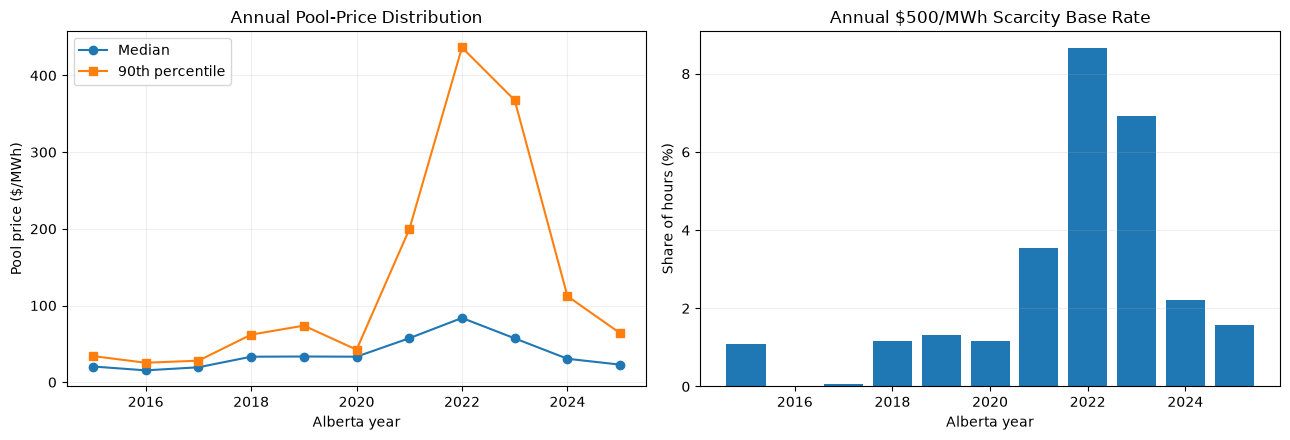

In [11]:
# ---------------------------------------------------------------------
# Plot annual price and scarcity base rates
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2, figsize = (13, 4.5),
)

axes[0].plot(
    annual_outcome_audit.index,
    annual_outcome_audit["median_pool_price"],
    marker = "o",
    label = "Median",
)

axes[0].plot(
    annual_outcome_audit.index,
    annual_outcome_audit["price_90th_percentile"],
    marker = "s",
    label = "90th percentile",
)

axes[0].set(
    title = "Annual Pool-Price Distribution",
    xlabel = "Alberta year",
    ylabel = "Pool price ($/MWh)",
)

axes[0].grid(alpha = 0.20)
axes[0].legend()

axes[1].bar(
    annual_outcome_audit.index,
    annual_outcome_audit["scarcity_500_rate"],
)

axes[1].set(
    title = "Annual $500/MWh Scarcity Base Rate",
    xlabel = "Alberta year",
    ylabel = "Share of hours (%)",
)

axes[1].grid(axis = "y", alpha = 0.20)

plt.tight_layout()
plt.show()

## 5. Chronological validation design

The primary validation scheme uses expanding annual windows: 

| Training period | Evaluation period |
|---|---|
| 2015–2019 | 2020 |
| 2015–2020 | 2021 |
| 2015–2021 | 2022 |
| 2015–2022 | 2023 |
| 2015–2023 | 2024 |
| 2015–2024 | 2025 |

Hyperparameters are selected using only blocked annual folds inside each outer training period.

No random train/test split is used.

Because the evaluation years have already been examined descriptively in earlier notebooks, the results are described as **chronological pseudo-out-of-period evaluation**, not as performance on a previously untouched holdout.

Model comparison uses a common complete-case sample for the core feature set. This prevents differences in data coverage from being mistaken for improvements in model quality.

In [12]:
# ---------------------------------------------------------------------
# Define core model families and common samples
# ---------------------------------------------------------------------

CORE_MODEL_FAMILIES = [
    "Calendar",
    "Market memory",
    "Net load",
    "Supply adequacy",
    "Outages",
    "Intertie capability",
    "Fuel economics",
    "Offer stack",
]

CORE_FEATURES = list(dict.fromkeys(
    feature
    for family in CORE_MODEL_FAMILIES
    for feature in FEATURE_FAMILIES[family]
))

CORE_REQUIRED_COLUMNS = [
    "pool_price",
    "price_asinh",
    "scarcity_500",
    *CORE_FEATURES,
]

core_common_mask = (
    model_features[CORE_REQUIRED_COLUMNS]
    .notna()
    .all(axis=1)
)

long_history_mask = (
    model_features[
        [
            "pool_price",
            "price_asinh",
            "scarcity_500",
            *FEATURE_FAMILIES["Calendar"],
        ]
    ]
    .notna()
    .all(axis=1)
)

sample_audit = pd.DataFrame([
    {
        "sample": "Complete study sample",
        "hours": len(model_features),
        "coverage_pct": 100.0,
        "start": model_features["timestamp_alberta"].min(),
        "end": model_features["timestamp_alberta"].max(),
    },
    {
        "sample": "Long-history calendar sample",
        "hours": int(long_history_mask.sum()),
        "coverage_pct": long_history_mask.mean() * 100,
        "start": model_features.loc[long_history_mask, "timestamp_alberta"].min(),
        "end": model_features.loc[long_history_mask, "timestamp_alberta"].max(),
    },
    {
        "sample": "Core common model sample",
        "hours": int(core_common_mask.sum()),
        "coverage_pct": core_common_mask.mean() * 100,
        "start": model_features.loc[core_common_mask, "timestamp_alberta"].min(),
        "end": model_features.loc[core_common_mask, "timestamp_alberta"].max(),
    }
])

display(sample_audit.round({"coverage_pct": 3}))

,sample,hours,coverage_pct,start,end
0,Complete study sample,96432,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
1,Long-history calendar sample,96432,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00
2,Core common model sample,96405,99.972,2015-01-02 00:00:00-07:00,2025-12-31 23:00:00-07:00


In [13]:
# ---------------------------------------------------------------------
# Build expanding and rolling annual splits
# ---------------------------------------------------------------------

def expanding_year_splits(
    frame, 
    test_years = OUTER_TEST_YEARS,
):  
    splits = []

    for test_year in test_years: 
        train_mask = frame["year_alberta"].lt(test_year)
        test_mask = frame["year_alberta"].eq(test_year)

        if train_mask.any() and test_mask.any(): 
            splits.append({
                "test_year": test_year,
                "train_mask": train_mask,
                "test_mask": test_mask,
            })

    return splits

def rolling_year_splits(frame, window_years=5, test_years=OUTER_TEST_YEARS):
    splits = []

    for test_year in test_years:
        first_train_year = test_year - window_years

        train_mask = (
            frame["year_alberta"].ge(first_train_year)
            & frame["year_alberta"].lt(test_year)
        )
        test_mask = frame["year_alberta"].eq(test_year)

        if train_mask.any() and test_mask.any():
            splits.append({
                "test_year": test_year,
                "train_mask": train_mask,
                "test_mask": test_mask,
            })

    return splits

def inner_year_splits(
    training_frame,
    validation_years = INNER_VALIDATION_YEARS,
): 
    years = sorted(
        training_frame["year_alberta"].dropna().unique().tolist()
    )

    candidate_years = years[-validation_years:]
    splits = []

    for validation_year in candidate_years: 
        train_mask = (
            training_frame["year_alberta"].lt(validation_year)
        )

        validation_mask = (
            training_frame["year_alberta"].eq(validation_year)
        )

        if train_mask.any() and validation_mask.any(): 
            splits.append((train_mask, validation_mask))

    return splits

split_summary = pd.DataFrame([
    {
        "evaluation_year": split["test_year"],
        "training_start": model_features.loc[split["train_mask"], "year_alberta"].min(),
        "training_end": model_features.loc[split["train_mask"], "year_alberta"].max(),
        "training_hours": int(split["train_mask"].sum()),
        "evaluation_hours": int(split['test_mask'].sum()),
    }
    for split in expanding_year_splits(model_features)
])

display(split_summary)

,evaluation_year,training_start,training_end,training_hours,evaluation_hours
0,2020,2015,2019,43824,8784
1,2021,2015,2020,52608,8760
2,2022,2015,2021,61368,8760
3,2023,2015,2022,70128,8760
4,2024,2015,2023,78888,8784
5,2025,2015,2024,87672,8760


## 6. Evaluation metrics

Price models are assessed using raw-dollar errors:

- mean absolute error;
- median absolute error;
- signed mean error;
- RMSE as a tail-sensitive secondary diagnostic;
- pinball loss for median and upper-quantile models.

Scarcity models are assessed using:

- Brier score and Brier skill;
- average precision;
- ROC-AUC as a supplementary ranking measure;
- log loss;
- calibration slope and intercept;
- top-decile scarcity lift.

Accuracy and F1 are not primary metrics because they depend on an arbitrary classification threshold and can be misleading for a rare event.

In [14]:
# ---------------------------------------------------------------------
# Define scoring and evaluation helpers
# ---------------------------------------------------------------------

def safe_roc_auc(y_true, prediction): 
    if pd.Series(y_true).nunique() < 2: 
        return np.nan

    return roc_auc_score(y_true, prediction)

def safe_average_precision(y_true, prediction): 
    if pd.Series(y_true).sum() == 0: 
        return np.nan

    return average_precision_score(y_true, prediction)

def calibration_coefficients(y_true, probability): 
    probability = np.clip(
        np.asarray(probability, dtype = float), 1e-6, 1 - 1e-6
    )

    if pd.Series(y_true).nunique() < 2: 
        return np.nan, np.nan
    
    logit_probability = np.log(probability / (1 - probability)).reshape(-1, 1)

    calibration_model = LogisticRegression(
        C = 1e6, 
        solver = "lbfgs",
        max_iter = 2000,
    )

    calibration_model.fit(
        logit_probability, 
        y_true,
    )

    return(
        float(calibration_model.intercept_[0]),
        float(calibration_model.coef_[0, 0]),
    )

def prediction_loss(
    y_true,
    prediction,
    task, 
    quantile = None,
): 
    if task == "scarcity": 
        return brier_score_loss(
            y_true, 
            prediction,
        )

    if task == "price_quantile": 
        return mean_pinball_loss(
            y_true, 
            prediction, 
            alpha = quantile,
        )

    if task == "price_location": 
        return mean_absolute_error(
            y_true, 
            prediction,
        )

    raise ValueError(
        f"Unknown task: {task}"
    )

def summarize_prediction_frame(predictions): 
    rows = []

    grouping_columns = [
        "model", 
        "task", 
        "evaluation_year",
    ]

    for keys, group in predictions.groupby(
        grouping_columns,
        observed=True,
    ):
        model_name, task, evaluation_year = keys

        observed = group["observed"].to_numpy()
        predicted = group["prediction"].to_numpy()
        baseline = group["baseline_prediction"].to_numpy()

        row = {
            "model": model_name,
            "task": task,
            "evaluation_year": evaluation_year,
            "hours": len(group),
        }

        if task == "scarcity":
            brier = brier_score_loss(
                observed,
                predicted,
            )

            baseline_brier = brier_score_loss(
                observed,
                baseline,
            )

            intercept, slope = calibration_coefficients(
                observed,
                predicted,
            )

            top_decile_cutoff = np.nanquantile(
                predicted,
                0.90,
            )

            top_decile = predicted >= top_decile_cutoff
            base_rate = np.mean(observed)

            row.update({
                "brier_score": brier,
                "baseline_brier_score": baseline_brier,
                "brier_skill": (
                    1 - brier / baseline_brier
                    if baseline_brier > 0
                    else np.nan
                ),
                "log_loss": log_loss(
                    observed,
                    np.clip(predicted, 1e-6, 1 - 1e-6),
                    labels=[0, 1],
                ),
                "average_precision": safe_average_precision(
                    observed,
                    predicted,
                ),
                "roc_auc": safe_roc_auc(
                    observed,
                    predicted,
                ),
                "calibration_intercept": intercept,
                "calibration_slope": slope,
                "scarcity_base_rate": base_rate,
                "top_decile_scarcity_rate": (
                    np.mean(observed[top_decile])
                    if top_decile.any()
                    else np.nan
                ),
                "top_decile_scarcity_lift": (
                    np.mean(observed[top_decile]) / base_rate
                    if top_decile.any() and base_rate > 0
                    else np.nan
                ),
            })

        else:
            absolute_error = np.abs(
                observed - predicted
            )

            row.update({
                "mae": mean_absolute_error(
                    observed,
                    predicted,
                ),
                "median_absolute_error": np.median(
                    absolute_error
                ),
                "bias": np.mean(
                    predicted - observed
                ),
                "rmse": mean_squared_error(
                    observed,
                    predicted,
                ) ** 0.5,
                "baseline_mae": mean_absolute_error(
                    observed,
                    baseline,
                ),
            })

            if task == "price_quantile":
                quantile = float(
                    group["quantile"].iloc[0]
                )

                row["pinball_loss"] = mean_pinball_loss(
                    observed,
                    predicted,
                    alpha=quantile,
                )

                row["baseline_pinball_loss"] = (
                    mean_pinball_loss(
                        observed,
                        baseline,
                        alpha=quantile,
                    )
                )

        rows.append(row)

    return pd.DataFrame(rows)

## 7. Model-building functions

The notebook uses a compact hierarchy: 

1. unconditional reference; 
2. linear or regularized model;
3. smooth additive model; 
4. boosted nonlinear model; 

Each model class answers a different question.

- Linear models ask whether conventional conditional relationships reproduce the EDA.
- Regularization tests how correlated variables behave when they compete.
- Additive spline models test whether important relationships are nonlinear but mostly additive.
- Boosted trees test whether substantial nonlinear interaction structure remains.

Hyperparameters are selected within each outer training period using only earlier blocked years.

In [15]:
# ---------------------------------------------------------------------
# Build reusable linear and additive preprocessors
# ---------------------------------------------------------------------

def build_preprocessor(
    features,
    spline_features=None,
    n_knots=5,
):
    spline_features = (
        list(spline_features)
        if spline_features is not None
        else []
    )

    linear_features = [
        feature
        for feature in features
        if feature not in spline_features
    ]

    transformers = []

    if spline_features:
        spline_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)),
            ("scale", StandardScaler()),
        ])

        transformers.append(("smooth", spline_pipeline, spline_features))

    if linear_features:
        linear_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ])

        transformers.append(("linear", linear_pipeline, linear_features))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [16]:
# ---------------------------------------------------------------------
# Build model specifications
# ---------------------------------------------------------------------

def build_model(
    task,
    model_kind,
    features,
    parameters,
    spline_features=None,
    quantile=None,
):
    if model_kind in {"linear", "additive"}:
        preprocessor = build_preprocessor(
            features=features,
            spline_features=(
                spline_features
                if model_kind == "additive"
                else []
            ),
            n_knots=parameters.get("n_knots", 5),
        )

        if task == "scarcity":
            estimator = LogisticRegression(
                C=parameters.get("C", 1.0),
                penalty="l2",
                solver="lbfgs",
                max_iter=3000,
                random_state=RANDOM_SEED,
            )
        else:
            estimator = Ridge(
                alpha=parameters.get("alpha", 1.0)
            )

        return Pipeline([
            ("preprocess", preprocessor),
            ("model", estimator),
        ])

    if model_kind == "boosted":
        imputer = SimpleImputer(strategy="median")

        common_parameters = {
            "learning_rate": parameters.get("learning_rate", 0.05),
            "max_iter": parameters.get("max_iter", 250),
            "max_leaf_nodes": parameters.get("max_leaf_nodes", 15),
            "min_samples_leaf": parameters.get("min_samples_leaf", 50),
            "l2_regularization": parameters.get("l2_regularization", 1.0),
            "random_state": RANDOM_SEED,
        }

        if task == "scarcity":
            estimator = HistGradientBoostingClassifier(
                loss="log_loss",
                **common_parameters,
            )

        elif task == "price_quantile":
            estimator = HistGradientBoostingRegressor(
                loss="quantile",
                quantile=quantile,
                **common_parameters,
            )

        else:
            estimator = HistGradientBoostingRegressor(
                loss="absolute_error",
                **common_parameters,
            )

        return Pipeline([
            ("imputer", imputer),
            ("model", estimator),
        ])

    raise ValueError(
        f"Unknown model kind: {model_kind}"
    )

In [17]:
# ---------------------------------------------------------------------
# Define small, prespecified hyperparameter grids
# ---------------------------------------------------------------------

LINEAR_CLASSIFICATION_GRID = [
    {"C": value}
    for value in [0.1, 1.0, 10.0]
]

LINEAR_REGRESSION_GRID = [
    {"alpha": value}
    for value in [0.1, 1.0, 10.0]
]

ADDITIVE_CLASSIFICATION_GRID = [
    {
        "C": C,
        "n_knots": n_knots,
    }
    for C, n_knots in product(
        [0.1, 1.0],
        [4, 6],
    )
]

ADDITIVE_REGRESSION_GRID = [
    {
        "alpha": alpha,
        "n_knots": n_knots,
    }
    for alpha, n_knots in product(
        [1.0, 10.0],
        [4, 6],
    )
]

BOOSTED_GRID = [
    {
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": max_leaf_nodes,
        "min_samples_leaf": 50,
        "l2_regularization": regularization,
    }
    for max_leaf_nodes, regularization in product(
        [15, 31],
        [1.0, 10.0],
    )
]

In [18]:
# ---------------------------------------------------------------------
# Define nested tuning and outer evaluation
# ---------------------------------------------------------------------
def predict_model(model, X, task):
    return model.predict_proba(X)[:, 1] if task == "scarcity" else model.predict(X)


def convert_price_location_prediction(transformed_prediction):
    return np.sinh(transformed_prediction) * PRICE_SCALE_MWH


def select_parameters(
    training_frame, features, target, task, model_kind, parameter_grid,
    spline_features=None, quantile=None,
):
    inner_splits = inner_year_splits(training_frame)
    if not inner_splits:
        return parameter_grid[0]

    parameter_results = []

    for parameters in parameter_grid:
        losses = []

        for train_mask, validation_mask in inner_splits:
            inner_train = training_frame.loc[train_mask]
            inner_validation = training_frame.loc[validation_mask]

            model = build_model(
                task=task, model_kind=model_kind, features=features,
                parameters=parameters, spline_features=spline_features, quantile=quantile,
            )
            model.fit(inner_train[features], inner_train[target])

            prediction = predict_model(model, inner_validation[features], task)

            if task == "price_location":
                prediction = convert_price_location_prediction(prediction)
                observed = inner_validation["pool_price"].to_numpy()
            else:
                observed = inner_validation[target].to_numpy()

            losses.append(
                prediction_loss(observed, prediction, task=task, quantile=quantile)
            )

        parameter_results.append({
            "parameters": parameters,
            "mean_inner_loss": np.mean(losses),
        })

    return min(parameter_results, key=lambda x: x["mean_inner_loss"])["parameters"]


def run_outer_evaluation(
    frame, model_name, features, target, task, model_kind, parameter_grid,
    spline_features=None, quantile=None, sample_mask=None,
    split_type="expanding", rolling_window_years=5,
):
    if sample_mask is None:
        sample_mask = pd.Series(True, index=frame.index)

    evaluation_frame = frame.loc[sample_mask].dropna(subset=[target, *features]).copy()

    if split_type == "expanding":
        outer_splits = expanding_year_splits(evaluation_frame)
    elif split_type == "rolling":
        outer_splits = rolling_year_splits(
            evaluation_frame, window_years=rolling_window_years
        )
    else:
        raise ValueError(f"Unknown split type: {split_type}")

    prediction_frames, selected_parameter_rows, fitted_models = [], [], {}

    for split in outer_splits:
        test_year = split["test_year"]
        training_frame = evaluation_frame.loc[split["train_mask"]].copy()
        test_frame = evaluation_frame.loc[split["test_mask"]].copy()

        if model_kind == "unconditional":
            if task == "scarcity":
                baseline_value = training_frame[target].mean()
            elif task == "price_quantile":
                baseline_value = training_frame[target].quantile(quantile)
            else:
                baseline_value = training_frame["pool_price"].median()

            prediction = np.repeat(baseline_value, len(test_frame))
            selected_parameters, fitted_model = {}, None

        else:
            selected_parameters = select_parameters(
                training_frame=training_frame, features=features, target=target,
                task=task, model_kind=model_kind, parameter_grid=parameter_grid,
                spline_features=spline_features, quantile=quantile,
            )

            fitted_model = build_model(
                task=task, model_kind=model_kind, features=features,
                parameters=selected_parameters, spline_features=spline_features,
                quantile=quantile,
            )
            fitted_model.fit(training_frame[features], training_frame[target])
            prediction = predict_model(fitted_model, test_frame[features], task)

            if task == "price_location":
                prediction = convert_price_location_prediction(prediction)

        if task == "scarcity":
            observed = test_frame[target].to_numpy()
            baseline_value = training_frame[target].mean()
        elif task == "price_quantile":
            observed = test_frame[target].to_numpy()
            baseline_value = training_frame[target].quantile(quantile)
        else:
            observed = test_frame["pool_price"].to_numpy()
            baseline_value = training_frame["pool_price"].median()

        prediction_frames.append(pd.DataFrame({
            "timestamp_utc": test_frame["timestamp_utc"].to_numpy(),
            "year_alberta": test_frame["year_alberta"].to_numpy(),
            "structural_regime": test_frame["structural_regime"].astype(str).to_numpy(),
            "model": model_name,
            "task": task,
            "evaluation_year": test_year,
            "observed": observed,
            "prediction": prediction,
            "baseline_prediction": baseline_value,
            "quantile": quantile,
            "split_type": split_type,
        }))

        selected_parameter_rows.append({
            "model": model_name,
            "task": task,
            "evaluation_year": test_year,
            "parameters": json.dumps(selected_parameters, sort_keys=True),
        })

        fitted_models[test_year] = fitted_model

    return {
        "predictions": pd.concat(prediction_frames, ignore_index=True),
        "selected_parameters": pd.DataFrame(selected_parameter_rows),
        "fitted_models": fitted_models,
    }

## 8. Reference benchmarks

The first comparison establishes how much can be explained without rich fundamentals.

Price benchmarks:

1. unconditional training-sample median;
2. calendar-only regularized model;
3. calendar plus net load;
4. calendar plus physical tightness.

Scarcity benchmarks:

1. unconditional training prevalence;
2. calendar-only logistic model;
3. net-load-only logistic model;
4. thermal-headroom-only logistic model;
5. compact physical-tightness model.

Standalone discrimination is not treated as independent multivariate information.

In [19]:
# ---------------------------------------------------------------------
# Evaluate unconditional price and scarcity references
# ---------------------------------------------------------------------
model_results = {}

model_results["Unconditional price median"] = run_outer_evaluation(
    frame=model_features, model_name="Unconditional price median", features=[],
    target="pool_price", task="price_quantile", model_kind="unconditional",
    parameter_grid=[{}], quantile=0.50, sample_mask=core_common_mask,
)

model_results["Unconditional scarcity rate"] = run_outer_evaluation(
    frame=model_features, model_name="Unconditional scarcity rate", features=[],
    target="scarcity_500", task="scarcity", model_kind="unconditional",
    parameter_grid=[{}], sample_mask=core_common_mask,
)

In [20]:
# ---------------------------------------------------------------------
# Evaluate calendar and single-feature benchmarks
# ---------------------------------------------------------------------

benchmark_specifications = [
    {
        "name": "Calendar price location",
        "features": FEATURE_FAMILIES["Calendar"],
        "target": "price_asinh",
        "task": "price_location",
        "kind": "linear",
        "grid": LINEAR_REGRESSION_GRID,
        "splines": [],
    },
    {
        "name": "Calendar scarcity",
        "features": FEATURE_FAMILIES["Calendar"],
        "target": "scarcity_500",
        "task": "scarcity",
        "kind": "linear",
        "grid": LINEAR_CLASSIFICATION_GRID,
        "splines": [],
    },
    {
        "name": "Net-load scarcity",
        "features": ["net_load_mw"],
        "target": "scarcity_500",
        "task": "scarcity",
        "kind": "additive",
        "grid": ADDITIVE_CLASSIFICATION_GRID,
        "splines": ["net_load_mw"],
    },
    {
        "name": "Thermal-headroom scarcity",
        "features": ["thermal_headroom_mw"],
        "target": "scarcity_500",
        "task": "scarcity",
        "kind": "additive",
        "grid": ADDITIVE_CLASSIFICATION_GRID,
        "splines": ["thermal_headroom_mw"],
    },
    {
        "name": "Compact physical scarcity",
        "features": [
            *FEATURE_FAMILIES["Calendar"],
            "net_load_mw",
            "thermal_headroom_mw",
            "total_outage_mw",
            "import_atc_mw",
        ],
        "target": "scarcity_500",
        "task": "scarcity",
        "kind": "additive",
        "grid": ADDITIVE_CLASSIFICATION_GRID,
        "splines": [
            "net_load_mw",
            "thermal_headroom_mw",
            "total_outage_mw",
            "import_atc_mw",
        ],
    },
]

for specification in benchmark_specifications:
    model_results[specification["name"]] = (
        run_outer_evaluation(
            frame=model_features,
            model_name=specification["name"],
            features=specification["features"],
            target=specification["target"],
            task=specification["task"],
            model_kind=specification["kind"],
            parameter_grid=specification["grid"],
            spline_features=specification["splines"],
            sample_mask=core_common_mask,
        )
    )

In [21]:
# ---------------------------------------------------------------------
# Summarize benchmark performance
# ---------------------------------------------------------------------

benchmark_predictions = pd.concat(
    [
        result["predictions"]
        for result in model_results.values()
    ],
    ignore_index=True,
)

benchmark_metrics = summarize_prediction_frame(benchmark_predictions)

display(
    benchmark_metrics
    .sort_values(["task", "evaluation_year", "model"])
    .round(4)
)

,model,task,evaluation_year,hours,mae,median_absolute_error,bias,rmse,baseline_mae,brier_score,baseline_brier_score,brier_skill,log_loss,average_precision,roc_auc,calibration_intercept,calibration_slope,scarcity_base_rate,top_decile_scarcity_rate,top_decile_scarcity_lift,pinball_loss,baseline_pinball_loss
0,Calendar price location,price_location,2020,8784,20.2479,5.3385,-17.3688,92.9663,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Calendar price location,price_location,2021,8760,71.5471,27.3500,-71.3483,154.9265,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Calendar price location,price_location,2022,8760,126.9674,48.4703,-126.6268,234.1343,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Calendar price location,price_location,2023,8759,97.4201,21.3993,-90.7166,203.6824,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Calendar price location,price_location,2024,8784,50.2376,24.2381,-15.8390,124.4078,45.5669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Calendar price location,price_location,2025,8760,41.1765,26.6694,2.6797,103.1492,34.2551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,Unconditional price median,price_quantile,2020,8784,23.1390,8.5800,-21.7460,94.6584,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.5695,11.5695
31,Unconditional price median,price_quantile,2021,8760,74.2777,29.6200,-74.2125,157.5301,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.1389,37.1389
32,Unconditional price median,price_quantile,2022,8760,132.6480,53.8000,-132.4831,239.2365,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.3240,66.3240
33,Unconditional price median,price_quantile,2023,8759,103.5879,25.4650,-101.1566,209.8252,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.7939,51.7939


#### Benchmark Interpretation


## 9. Linear multivariate competition


In [22]:
# ---------------------------------------------------------------------
# Evaluate multivariate models
# ---------------------------------------------------------------------

linear_price_result = run_outer_evaluation(
    frame=model_features,
    model_name="Core linear price location",
    features=CORE_FEATURES,
    target="price_asinh",
    task="price_location",
    model_kind="linear",
    parameter_grid=LINEAR_REGRESSION_GRID,
    sample_mask=core_common_mask,
)

linear_scarcity_result = run_outer_evaluation(
    frame=model_features,
    model_name="Core linear scarcity",
    features=CORE_FEATURES,
    target="scarcity_500",
    task="scarcity",
    model_kind="linear",
    parameter_grid=LINEAR_CLASSIFICATION_GRID,
    sample_mask=core_common_mask,
)

model_results["Core linear price location"] = (linear_price_result)

model_results["Core linear scarcity"] = (linear_scarcity_result)

linear_metrics = summarize_prediction_frame(
    pd.concat(
        [
            linear_price_result["predictions"],
            linear_scarcity_result["predictions"],
        ],
        ignore_index=True,
    )
)

display(linear_metrics.round(4))

,model,task,evaluation_year,hours,mae,median_absolute_error,bias,rmse,baseline_mae,brier_score,baseline_brier_score,brier_skill,log_loss,average_precision,roc_auc,calibration_intercept,calibration_slope,scarcity_base_rate,top_decile_scarcity_rate,top_decile_scarcity_lift
0,Core linear price location,price_location,2020,8784,13.9994,4.5675,-1.6762,64.7565,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Core linear price location,price_location,2021,8760,37.5085,10.9067,-25.6197,88.6432,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Core linear price location,price_location,2022,8760,64.0591,12.1085,-4.2228,165.8520,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Core linear price location,price_location,2023,8759,57.6702,20.7003,-16.9602,115.2726,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Core linear price location,price_location,2024,8784,40.1977,23.2241,19.7254,110.6485,45.5669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Core linear price location,price_location,2025,8760,25.9592,14.4368,7.2641,71.4394,34.2551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Core linear scarcity,scarcity,2020,8784,NaN,NaN,NaN,NaN,NaN,0.0028,0.0115,0.7565,0.0095,0.9207,0.9986,0.1394,1.1881,0.0116,0.1160,9.9932
7,Core linear scarcity,scarcity,2021,8760,NaN,NaN,NaN,NaN,NaN,0.0146,0.0349,0.5801,0.0499,0.8015,0.9869,0.6370,1.2049,0.0354,0.3356,9.4839
8,Core linear scarcity,scarcity,2022,8760,NaN,NaN,NaN,NaN,NaN,0.0305,0.0846,0.6390,0.1026,0.8401,0.9769,-0.0738,0.8928,0.0865,0.6975,8.0607
9,Core linear scarcity,scarcity,2023,8759,NaN,NaN,NaN,NaN,NaN,0.0256,0.0667,0.6162,0.0888,0.8491,0.9794,0.9779,1.1996,0.0692,0.5959,8.6129


In [23]:
# ---------------------------------------------------------------------
# Inspect coefficient stability across outer folds
# ---------------------------------------------------------------------

def extract_linear_coefficients(
    evaluation_result,
    features,
):
    coefficient_rows = []

    for year, fitted_model in (
        evaluation_result["fitted_models"].items()
    ):
        if fitted_model is None:
            continue

        transformed_names = (fitted_model["preprocess"].get_feature_names_out())

        coefficients = (fitted_model["model"].coef_)

        if coefficients.ndim > 1:
            coefficients = coefficients[0]

        for name, coefficient in zip(
            transformed_names,
            coefficients,
        ):
            coefficient_rows.append({
                "evaluation_year": year,
                "transformed_feature": name,
                "coefficient": coefficient,
            })

    return pd.DataFrame(coefficient_rows)


linear_scarcity_coefficients = (
    extract_linear_coefficients(
        linear_scarcity_result,
        CORE_FEATURES,
    )
)

display(
    linear_scarcity_coefficients.groupby("transformed_feature").agg(
        median_coefficient=("coefficient", "median"),
        minimum_coefficient=("coefficient", "min"),
        maximum_coefficient=("coefficient", "max"),
        positive_fold_share=("coefficient", lambda series: series.gt(0).mean()),
    )
    .sort_values("median_coefficient", key=lambda series: series.abs(), ascending=False).round(4)
)

,median_coefficient,minimum_coefficient,maximum_coefficient,positive_fold_share
transformed_feature,,,,
cheap_supply_headroom_100_mw,-3.0486,-3.3288,-2.7284,0.0000
net_load_mw,0.6217,0.3679,0.8149,1.0000
pool_price_lag_1h,0.5980,0.3121,0.8030,1.0000
hour_cos,-0.5216,-0.6521,-0.4874,0.0000
total_outage_mw,0.4638,0.0092,0.6551,1.0000
thermal_headroom_mw,-0.2620,-0.6886,-0.0473,0.0000
month_sin,0.2539,0.0907,0.4023,1.0000
import_atc_mw,-0.2134,-0.2766,-0.1408,0.0000
prior_price_volatility_24h,0.1803,0.1262,0.2162,1.0000


### Linear-model decision


## 10. Smooth additive models


In [24]:
# ---------------------------------------------------------------------
# Evaluate smooth additive price/scarcity models
# ---------------------------------------------------------------------

CORE_SPLINE_FEATURES = [
    "pool_price_lag_1h",
    "pool_price_lag_24h",
    "prior_price_volatility_24h",
    "net_load_mw",
    "thermal_headroom_mw",
    "domestic_available_margin_mw",
    "total_outage_mw",
    "import_atc_mw",
    "gas_price",
    "cheap_supply_headroom_100_mw",
]

additive_price_result = run_outer_evaluation(
    frame=model_features,
    model_name="Core additive price location",
    features=CORE_FEATURES,
    target="price_asinh",
    task="price_location",
    model_kind="additive",
    parameter_grid=ADDITIVE_REGRESSION_GRID,
    spline_features=CORE_SPLINE_FEATURES,
    sample_mask=core_common_mask,
)

additive_scarcity_result = run_outer_evaluation(
    frame=model_features,
    model_name="Core additive scarcity",
    features=CORE_FEATURES,
    target="scarcity_500",
    task="scarcity",
    model_kind="additive",
    parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
    spline_features=CORE_SPLINE_FEATURES,
    sample_mask=core_common_mask,
)

model_results["Core additive price location"] = (additive_price_result)
model_results["Core additive scarcity"] = (additive_scarcity_result)

additive_comparison_predictions = pd.concat(
    [
        linear_price_result["predictions"],
        additive_price_result["predictions"],
        linear_scarcity_result["predictions"],
        additive_scarcity_result["predictions"],
    ],
    ignore_index=True,
)

additive_comparison_metrics = (summarize_prediction_frame(additive_comparison_predictions))

display(additive_comparison_metrics.sort_values(["task", "evaluation_year", "model"]).round(4))

,model,task,evaluation_year,hours,mae,median_absolute_error,bias,rmse,baseline_mae,brier_score,baseline_brier_score,brier_skill,log_loss,average_precision,roc_auc,calibration_intercept,calibration_slope,scarcity_base_rate,top_decile_scarcity_rate,top_decile_scarcity_lift
0,Core additive price location,price_location,2020,8784,8.5162,2.2719,-3.1565,37.4050,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,Core linear price location,price_location,2020,8784,13.9994,4.5675,-1.6762,64.7565,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Core additive price location,price_location,2021,8760,29.2677,7.6602,-18.8803,73.3147,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,Core linear price location,price_location,2021,8760,37.5085,10.9067,-25.6197,88.6432,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Core additive price location,price_location,2022,8760,54.3641,11.7773,8.1191,113.5322,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,Core linear price location,price_location,2022,8760,64.0591,12.1085,-4.2228,165.8520,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Core additive price location,price_location,2023,8759,52.3902,17.3611,-18.6836,101.4090,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,Core linear price location,price_location,2023,8759,57.6702,20.7003,-16.9602,115.2726,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Core additive price location,price_location,2024,8784,21.0462,6.5060,1.5524,53.9934,45.5669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Core linear price location,price_location,2024,8784,40.1977,23.2241,19.7254,110.6485,45.5669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


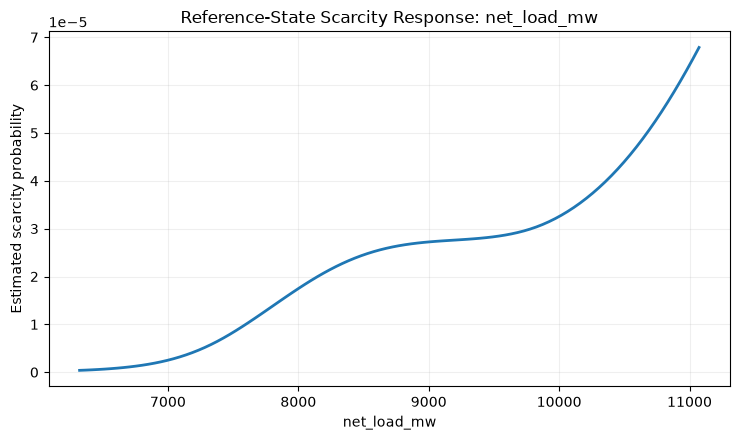

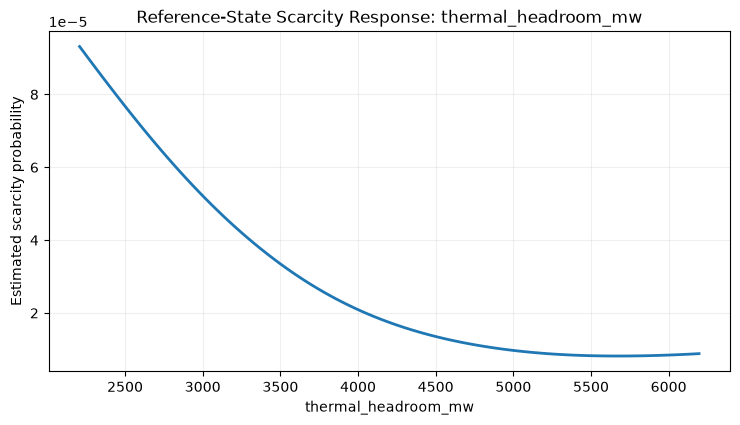

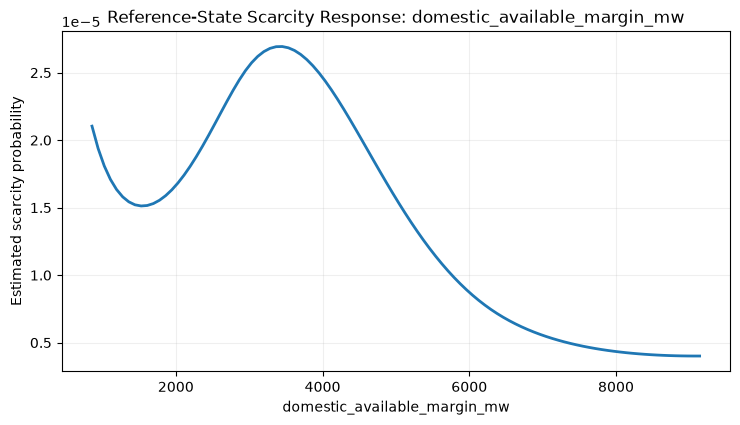

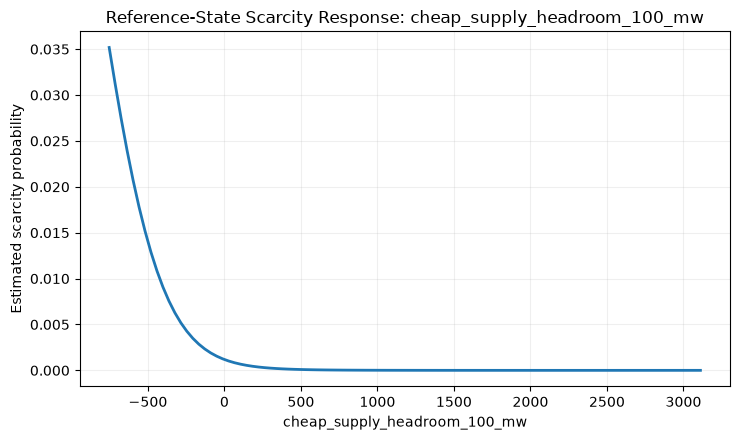

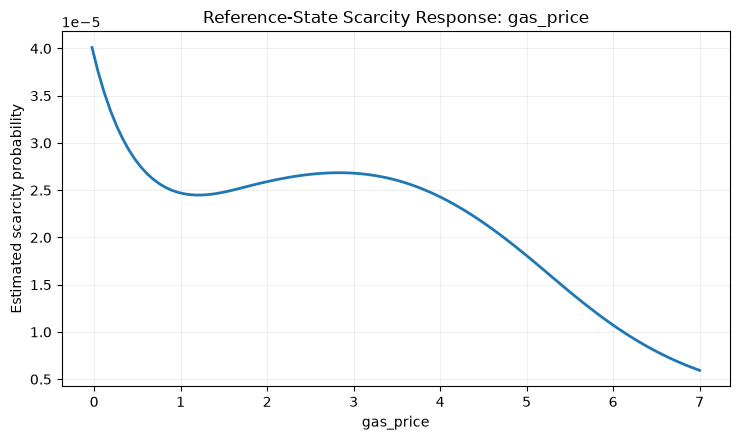

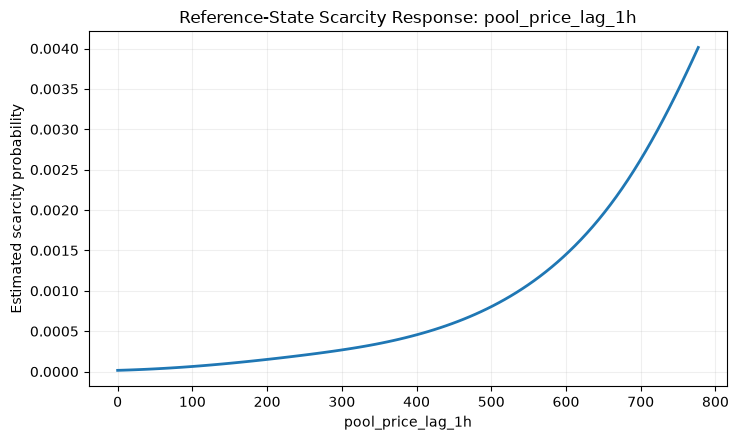

In [25]:
# ---------------------------------------------------------------------
# Plot reference-state additive response curves
# ---------------------------------------------------------------------

def plot_reference_response(
    fitted_model,
    frame,
    features,
    feature,
    task,
    title,
    quantile_range=(0.01, 0.99),
    grid_points=100,
):
    reference = (frame[features].median(numeric_only=True).to_frame().T)

    low, high = frame[feature].quantile(list(quantile_range))

    grid = np.linspace(
        low,
        high,
        grid_points,
    )

    response_frame = pd.concat([reference] * grid_points, ignore_index=True)

    response_frame[feature] = grid

    response = predict_model(fitted_model, response_frame[features], task)

    if task == "price_location":
        response = convert_price_location_prediction(
            response
        )

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    ax.plot(
        grid,
        response,
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel(feature)

    ax.set_ylabel(
        "Estimated scarcity probability"
        if task == "scarcity"
        else "Estimated pool-price location ($/MWh)"
    )

    ax.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()


FINAL_ADDITIVE_YEAR = max(additive_scarcity_result["fitted_models"])
FINAL_ADDITIVE_SCARCITY_MODEL = (additive_scarcity_result["fitted_models"][FINAL_ADDITIVE_YEAR])
FINAL_ADDITIVE_PRICE_MODEL = (additive_price_result["fitted_models"][FINAL_ADDITIVE_YEAR])

response_curve_features = [
    "net_load_mw",
    "thermal_headroom_mw",
    "domestic_available_margin_mw",
    "cheap_supply_headroom_100_mw",
    "gas_price",
    "pool_price_lag_1h",
]

for feature in response_curve_features:
    plot_reference_response(
        fitted_model=FINAL_ADDITIVE_SCARCITY_MODEL,
        frame=model_features.loc[core_common_mask],
        features=CORE_FEATURES,
        feature=feature,
        task="scarcity",
        title=("Reference-State Scarcity Response: "f"{feature}"),
    )

### Additive-model decision


## 11. Mechanism hierarchy and redundancy


In [26]:
# ---------------------------------------------------------------------
# Define mechanism-directed feature specifications
# ---------------------------------------------------------------------
def combine_families(*families):
    return list(dict.fromkeys(
        feature for family in families for feature in FEATURE_FAMILIES[family]
    ))

MECHANISM_SPECIFICATIONS = {
    "Calendar": combine_families("Calendar"),
    "Calendar + weather": combine_families("Calendar", "Weather"),
    "Calendar + demand and renewables": combine_families("Calendar", "Demand and renewables"),
    "Calendar + net load": combine_families("Calendar", "Net load"),
    "Calendar + net load + adequacy": combine_families("Calendar", "Net load", "Supply adequacy"),
    "Physical + outages": combine_families("Calendar", "Net load", "Supply adequacy", "Outages"),
    "Physical + capability": combine_families(
        "Calendar", "Net load", "Supply adequacy", "Outages", "Intertie capability"
    ),
    "Physical + fuel": combine_families(
        "Calendar", "Net load", "Supply adequacy", "Outages",
        "Intertie capability", "Fuel economics"
    ),
    "Physical + offer stack": combine_families(
        "Calendar", "Net load", "Supply adequacy", "Outages",
        "Intertie capability", "Fuel economics", "Offer stack"
    ),
    "Physical + offer stack + memory": CORE_FEATURES,
}

mechanism_common_columns = list(dict.fromkeys(
    feature for features in MECHANISM_SPECIFICATIONS.values() for feature in features
))

mechanism_common_mask = model_features[
    ["pool_price", "scarcity_500", *mechanism_common_columns]
].notna().all(axis=1)

print("Mechanism common-sample hours:", f"{mechanism_common_mask.sum():,}")

Mechanism common-sample hours: 96,405


In [27]:
# ---------------------------------------------------------------------
# Evaluate mechanism specifications for scarcity
# ---------------------------------------------------------------------
mechanism_results = {}

for name, features in MECHANISM_SPECIFICATIONS.items():
    spline_features = [
        feature for feature in features if feature not in FEATURE_FAMILIES["Calendar"]
    ]

    mechanism_results[name] = run_outer_evaluation(
        frame=model_features, model_name=name, features=features,
        target="scarcity_500", task="scarcity", model_kind="additive",
        parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
        spline_features=spline_features, sample_mask=mechanism_common_mask,
    )

mechanism_predictions = pd.concat(
    [result["predictions"] for result in mechanism_results.values()],
    ignore_index=True,
)

mechanism_metrics = summarize_prediction_frame(mechanism_predictions)

display(
    mechanism_metrics[
        ["model", "evaluation_year", "brier_score", "brier_skill",
         "average_precision", "roc_auc", "calibration_slope",
         "top_decile_scarcity_lift"]
    ]
    .sort_values(["evaluation_year", "brier_score"])
    .round(4)
)

,model,evaluation_year,brier_score,brier_skill,average_precision,roc_auc,calibration_slope,top_decile_scarcity_lift
48,Physical + offer stack + memory,2020,0.0033,0.7143,0.9156,0.9986,0.9387,9.9932
42,Physical + offer stack,2020,0.0039,0.6627,0.8521,0.9975,0.9234,9.9932
54,Physical + outages,2020,0.0063,0.4506,0.7399,0.9890,1.1349,9.8952
30,Physical + capability,2020,0.0064,0.4438,0.7518,0.9911,1.1511,9.8952
36,Physical + fuel,2020,0.0081,0.2948,0.6617,0.9910,1.1085,9.9932
18,Calendar + net load + adequacy,2020,0.0085,0.2582,0.6278,0.9862,1.2280,9.6993
24,Calendar + weather,2020,0.0088,0.2379,0.5115,0.9607,1.3418,9.1114
6,Calendar + demand and renewables,2020,0.0107,0.0655,0.2046,0.9370,1.1031,7.9358
12,Calendar + net load,2020,0.0109,0.0493,0.2051,0.9229,1.2287,7.7398
0,Calendar,2020,0.0115,-0.0045,0.0191,0.6616,0.3245,1.7635


In [28]:
# ---------------------------------------------------------------------
# Summarize mean performance across folds
# ---------------------------------------------------------------------

mechanism_summary = (
    mechanism_metrics
    .groupby("model")
    .agg(
        evaluation_years=("evaluation_year", "nunique"),
        mean_brier_score=("brier_score", "mean"),
        median_brier_skill=("brier_skill", "median"),
        mean_average_precision=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        median_calibration_slope=("calibration_slope", "median"),
        mean_top_decile_lift=("top_decile_scarcity_lift", "mean"),
    ).sort_values("mean_brier_score")
)

display(mechanism_summary.round(4))

,evaluation_years,mean_brier_score,median_brier_skill,mean_average_precision,mean_roc_auc,median_calibration_slope,mean_top_decile_lift
model,,,,,,,
Physical + offer stack + memory,6,0.0162,0.5801,0.8338,0.9860,0.9111,9.2599
Physical + offer stack,6,0.0259,0.3695,0.6914,0.9688,0.7992,8.4764
Calendar + net load + adequacy,6,0.0320,0.1762,0.4964,0.9377,0.6378,7.5255
Calendar + weather,6,0.0337,0.1507,0.3763,0.8797,0.8539,6.3787
Calendar + net load,6,0.0358,0.0753,0.3048,0.8910,0.9109,6.0908
Calendar + demand and renewables,6,0.0361,0.0988,0.2882,0.8962,0.6970,6.1567
Calendar,6,0.0387,0.0133,0.0792,0.7066,0.6047,2.3667
Physical + outages,6,0.0408,0.1232,0.5154,0.9470,0.5988,7.6328
Physical + fuel,6,0.0476,0.1613,0.4704,0.9234,0.5284,7.0213


### Mechanism-hierarchy interpretation


## 12. Leave-one-family-out ablation


In [29]:
ablation_results = {"Core additive scarcity": additive_scarcity_result}

for omitted in CORE_MODEL_FAMILIES:
    features = combine_families(*(f for f in CORE_MODEL_FAMILIES if f != omitted))
    splines = [f for f in features if f not in FEATURE_FAMILIES["Calendar"]]
    name = f"Without {omitted}"
    ablation_results[name] = run_outer_evaluation(
        frame=model_features, model_name=name, features=features,
        target="scarcity_500", task="scarcity", model_kind="additive",
        parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
        spline_features=splines, sample_mask=core_common_mask,
    )

ablation_predictions = pd.concat(
    (r["predictions"] for r in ablation_results.values()), ignore_index=True
)
ablation_metrics = summarize_prediction_frame(ablation_predictions)

full_brier = (
    ablation_metrics[ablation_metrics.model.eq("Core additive scarcity")]
    [["evaluation_year", "brier_score"]]
    .rename(columns={"brier_score": "full_model_brier"})
)

ablation_comparison = ablation_metrics.merge(
    full_brier, on="evaluation_year", how="left"
)
ablation_comparison["brier_loss_increase"] = (
    ablation_comparison.brier_score - ablation_comparison.full_model_brier
)

display(
    ablation_comparison[
        ["model", "evaluation_year", "brier_loss_increase",
         "average_precision", "calibration_slope"]
    ].sort_values(["model", "evaluation_year"]).round(5)
)


,model,evaluation_year,brier_loss_increase,average_precision,calibration_slope
0,Core additive scarcity,2020,0.00000,0.91563,0.93865
1,Core additive scarcity,2021,0.00000,0.73336,0.85589
2,Core additive scarcity,2022,0.00000,0.82037,0.80720
3,Core additive scarcity,2023,0.00000,0.83509,1.08234
4,Core additive scarcity,2024,0.00000,0.87481,0.88352
5,Core additive scarcity,2025,0.00000,0.82361,1.03276
6,Without Calendar,2020,-0.00029,0.92715,1.00803
7,Without Calendar,2021,0.00041,0.72254,0.91433
8,Without Calendar,2022,-0.00554,0.85262,0.98718
9,Without Calendar,2023,0.00311,0.82347,1.07221


In [30]:
ablation_summary = (ablation_comparison[ablation_comparison.model.ne("Core additive scarcity")]
    .groupby("model").agg(
        median_brier_loss_increase=("brier_loss_increase", "median"),
        mean_brier_loss_increase=("brier_loss_increase", "mean"),
        folds_where_removal_hurts=("brier_loss_increase", lambda x: (x > 0).sum()),
        folds_evaluated=("evaluation_year", "nunique"))
    .sort_values("median_brier_loss_increase", ascending=False))

display(ablation_summary.round(6))


,median_brier_loss_increase,mean_brier_loss_increase,folds_where_removal_hurts,folds_evaluated
model,,,,
Without Market memory,0.010535,0.009740,6,6
Without Offer stack,0.001270,0.001728,6,6
Without Net load,0.000343,0.000292,4,6
Without Fuel economics,0.000269,-0.000085,3,6
Without Outages,0.000126,0.000154,4,6
Without Calendar,0.000059,-0.000475,3,6
Without Intertie capability,-0.000047,0.000440,3,6
Without Supply adequacy,-0.000164,0.000040,2,6


### Ablation decision


## 13. Explicit interaction tests


In [31]:
# ---------------------------------------------------------------------
# Construct prereigstered interaction terms
# ---------------------------------------------------------------------

interaction_features = model_features.copy()
interaction_features["is_evening"] = master.hour_alberta.between(16, 20).astype("int8")

INTERACTION_DEFINITIONS = {
    "Net load × outages": ("net_load_mw", "total_outage_mw"),
    "Thermal headroom × outages": ("thermal_headroom_mw", "total_outage_mw"),
    "Available margin × import capability": ("domestic_available_margin_mw", "import_atc_mw"),
    "Thermal headroom × cheap-supply headroom": ("thermal_headroom_mw", "cheap_supply_headroom_100_mw"),
    "Gas price × thermal headroom": ("gas_price", "thermal_headroom_mw"),
    "Prior price × evening": ("pool_price_lag_1h", "is_evening"),
}

interaction_columns = {}
for name, (left, right) in INTERACTION_DEFINITIONS.items():
    col = name.lower().replace(" × ", "_x_").replace(" ", "_").replace("-", "_")
    interaction_features[col] = interaction_features[left] * interaction_features[right]
    interaction_columns[name] = col

display(pd.Series(interaction_columns, name="interaction_column").to_frame())


,interaction_column
Net load × outages,net_load_x_outages
Thermal headroom × outages,thermal_headroom_x_outages
Available margin × import capability,available_margin_x_import_capability
Thermal headroom × cheap-supply headroom,thermal_headroom_x_cheap_supply_headroom
Gas price × thermal headroom,gas_price_x_thermal_headroom
Prior price × evening,prior_price_x_evening


In [32]:
# ---------------------------------------------------------------------
# Evaluate explicit interaction additions
# ---------------------------------------------------------------------

interaction_results = {
    "Additive core without explicit interaction": run_outer_evaluation(
        frame=interaction_features,
        model_name="Additive core without explicit interaction",
        features=CORE_FEATURES,
        target="scarcity_500",
        task="scarcity",
        model_kind="additive",
        parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
        spline_features=CORE_SPLINE_FEATURES,
        sample_mask=core_common_mask,
    )
}

for name, col in interaction_columns.items():
    model_name = f"Core + {name}"
    interaction_results[model_name] = run_outer_evaluation(
        frame=interaction_features,
        model_name=model_name,
        features=[*CORE_FEATURES, col],
        target="scarcity_500",
        task="scarcity",
        model_kind="additive",
        parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
        spline_features=CORE_SPLINE_FEATURES,
        sample_mask=core_common_mask,
    )

interaction_predictions = pd.concat(
    (r["predictions"] for r in interaction_results.values()), ignore_index=True
)
interaction_metrics = summarize_prediction_frame(interaction_predictions)

interaction_base = (
    interaction_metrics[interaction_metrics.model.eq(
        "Additive core without explicit interaction"
    )][["evaluation_year", "brier_score"]]
    .rename(columns={"brier_score": "base_brier_score"})
)

interaction_comparison = interaction_metrics.merge(
    interaction_base, on="evaluation_year", how="left"
)
interaction_comparison["brier_improvement"] = (
    interaction_comparison.base_brier_score - interaction_comparison.brier_score
)

display(
    interaction_comparison[
        ["model", "evaluation_year", "brier_improvement",
         "average_precision", "calibration_slope"]
    ].sort_values(["model", "evaluation_year"]).round(6)
)


,model,evaluation_year,brier_improvement,average_precision,calibration_slope
0,Additive core without explicit interaction,2020,0.000000,0.915634,0.938653
1,Additive core without explicit interaction,2021,0.000000,0.733364,0.855889
2,Additive core without explicit interaction,2022,0.000000,0.820369,0.807200
3,Additive core without explicit interaction,2023,0.000000,0.835095,1.082340
4,Additive core without explicit interaction,2024,0.000000,0.874805,0.883516
5,Additive core without explicit interaction,2025,0.000000,0.823613,1.032762
6,Core + Available margin × import capability,2020,0.000036,0.916533,0.950202
7,Core + Available margin × import capability,2021,-0.000452,0.726609,0.838850
8,Core + Available margin × import capability,2022,-0.000608,0.818293,0.799307
9,Core + Available margin × import capability,2023,0.000165,0.834575,1.044952


In [33]:
# ---------------------------------------------------------------------
# Summarize interaction stability
# ---------------------------------------------------------------------

interaction_summary = (
    interaction_comparison[interaction_comparison.model.ne(
        "Additive core without explicit interaction"
    )]
    .groupby("model")
    .agg(
        median_brier_improvement=("brier_improvement", "median"),
        mean_brier_improvement=("brier_improvement", "mean"),
        folds_improved=("brier_improvement", lambda x: (x > 0).sum()),
        folds_evaluated=("evaluation_year", "nunique"),
    )
    .sort_values("median_brier_improvement", ascending=False)
)

display(interaction_summary.round(6))


,median_brier_improvement,mean_brier_improvement,folds_improved,folds_evaluated
model,,,,
Core + Available margin × import capability,0.000101,-0.000066,4,6
Core + Thermal headroom × outages,0.000008,-0.000036,3,6
Core + Prior price × evening,-0.000035,-0.000064,2,6
Core + Gas price × thermal headroom,-0.000044,-0.000270,3,6
Core + Thermal headroom × cheap-supply headroom,-0.000059,-0.000114,2,6
Core + Net load × outages,-0.000073,-0.000388,2,6


### Interaction decision


## 14. Flexible nonlinear and upper-quantile models


In [34]:
# ---------------------------------------------------------------------
# Evaluate boosted scarcity and price-quantile models
# ---------------------------------------------------------------------

boosted_scarcity_result = run_outer_evaluation(
    frame=model_features, model_name="Core boosted scarcity",
    features=CORE_FEATURES, target="scarcity_500", task="scarcity",
    model_kind="boosted", parameter_grid=BOOSTED_GRID,
    sample_mask=core_common_mask)

boosted_median_result = run_outer_evaluation(
    frame=model_features, model_name="Core boosted median price",
    features=CORE_FEATURES, target="pool_price", task="price_quantile",
    model_kind="boosted", parameter_grid=BOOSTED_GRID, quantile=.50,
    sample_mask=core_common_mask)

boosted_upper_quantile_result = run_outer_evaluation(
    frame=model_features, model_name="Core boosted 90th-percentile price",
    features=CORE_FEATURES, target="pool_price", task="price_quantile",
    model_kind="boosted", parameter_grid=BOOSTED_GRID, quantile=.90,
    sample_mask=core_common_mask)

model_results.update({
    "Core boosted scarcity": boosted_scarcity_result,
    "Core boosted median price": boosted_median_result,
    "Core boosted 90th-percentile price": boosted_upper_quantile_result,
})

boosted_predictions = pd.concat(
    (r["predictions"] for r in [
        boosted_scarcity_result, boosted_median_result,
        boosted_upper_quantile_result
    ]), ignore_index=True)

boosted_metrics = summarize_prediction_frame(boosted_predictions)
display(boosted_metrics.round(4))

,model,task,evaluation_year,hours,mae,median_absolute_error,bias,rmse,baseline_mae,pinball_loss,baseline_pinball_loss,brier_score,baseline_brier_score,brier_skill,log_loss,average_precision,roc_auc,calibration_intercept,calibration_slope,scarcity_base_rate,top_decile_scarcity_rate,top_decile_scarcity_lift
0,Core boosted 90th-percentile price,price_quantile,2020,8784,11.0701,2.0925,8.6906,45.1694,27.2855,2.0588,13.9251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Core boosted 90th-percentile price,price_quantile,2021,8760,42.7268,6.3284,32.7688,95.5863,61.0258,8.2559,53.0819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Core boosted 90th-percentile price,price_quantile,2022,8760,73.3389,17.3305,61.3095,122.5568,105.3975,12.1456,91.5320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Core boosted 90th-percentile price,price_quantile,2023,8759,80.3434,39.2356,68.7707,119.5381,102.5637,12.6634,67.9309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Core boosted 90th-percentile price,price_quantile,2024,8784,42.9913,14.5753,39.2754,84.7164,92.2737,5.7855,27.8656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Core boosted 90th-percentile price,price_quantile,2025,8760,21.1005,9.7539,12.9805,49.5899,93.0135,5.3581,20.4548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Core boosted median price,price_quantile,2020,8784,7.0983,1.5134,-4.2863,33.9634,23.1390,3.5492,11.5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Core boosted median price,price_quantile,2021,8760,26.7777,8.1800,-18.5047,67.1778,74.2777,13.3889,37.1389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Core boosted median price,price_quantile,2022,8760,42.2216,8.4890,-11.9514,88.3015,132.6480,21.1108,66.3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Core boosted median price,price_quantile,2023,8759,38.1987,9.3946,-9.4360,81.0890,103.5879,19.0993,51.7939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# ---------------------------------------------------------------------
# Compare additive and boosted scarcity performance
# ---------------------------------------------------------------------

complexity_predictions = pd.concat(
    (r["predictions"] for r in [
        linear_scarcity_result, additive_scarcity_result,
        boosted_scarcity_result
    ]), ignore_index=True)

complexity_metrics = summarize_prediction_frame(complexity_predictions)

display(
    complexity_metrics[
        ["model", "evaluation_year", "brier_score", "brier_skill",
         "average_precision", "roc_auc", "calibration_intercept",
         "calibration_slope", "top_decile_scarcity_lift"]
    ].sort_values(["evaluation_year", "brier_score"]).round(4)
)

,model,evaluation_year,brier_score,brier_skill,average_precision,roc_auc,calibration_intercept,calibration_slope,top_decile_scarcity_lift
12,Core linear scarcity,2020,0.0028,0.7565,0.9207,0.9986,0.1394,1.1881,9.9932
0,Core additive scarcity,2020,0.0033,0.7143,0.9156,0.9986,-0.7348,0.9387,9.9932
6,Core boosted scarcity,2020,0.0034,0.7047,0.8981,0.9981,-0.1192,1.0161,9.9932
13,Core linear scarcity,2021,0.0146,0.5801,0.8015,0.9869,0.6370,1.2049,9.4839
1,Core additive scarcity,2021,0.0171,0.5110,0.7334,0.9788,-0.2977,0.8559,9.2903
7,Core boosted scarcity,2021,0.0176,0.4965,0.7260,0.9802,0.3105,0.8325,9.3226
8,Core boosted scarcity,2022,0.0303,0.6421,0.8420,0.9759,0.0452,0.8230,8.0211
14,Core linear scarcity,2022,0.0305,0.6390,0.8401,0.9769,-0.0738,0.8928,8.0607
2,Core additive scarcity,2022,0.0340,0.5982,0.8204,0.9720,-0.5522,0.8072,7.8364
3,Core additive scarcity,2023,0.0253,0.6208,0.8351,0.9776,0.4690,1.0823,8.4974


### Model-complexity decision


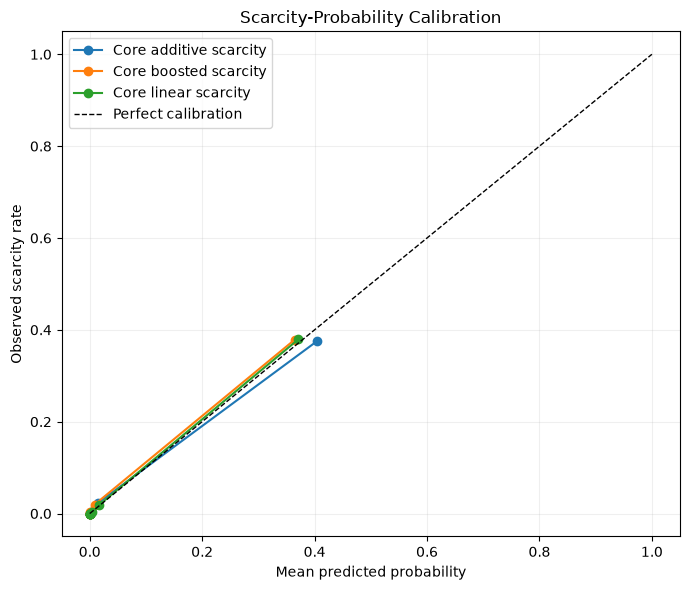

In [36]:
# ---------------------------------------------------------------------
# Plot scarcity calibration by model
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

for name, g in complexity_predictions.groupby("model"):
    observed, predicted = calibration_curve(
        g.observed, g.prediction, n_bins=10, strategy="quantile"
    )
    ax.plot(predicted, observed, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set(
    title="Scarcity-Probability Calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed scarcity rate",
)
ax.grid(alpha=.20)
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# ---------------------------------------------------------------------
# Calculate first-order accumulated local effects
# ---------------------------------------------------------------------

def first_order_ale(fitted_model, X, feature, task, bins=20):
    values = X[feature].dropna()
    edges = np.unique(values.quantile(np.linspace(0, 1, bins + 1)).to_numpy())
    if len(edges) < 3:
        raise ValueError(f"Insufficient unique values for ALE: {feature}")

    idx = np.clip(np.searchsorted(edges, X[feature], side="right") - 1, 0, len(edges) - 2)
    rows = []

    for i in range(len(edges) - 1):
        mask = idx == i
        if not np.any(mask):
            continue

        lower, upper = X.loc[mask].copy(), X.loc[mask].copy()
        lower[feature], upper[feature] = edges[i], edges[i + 1]

        rows.append({
            "bin": i,
            "lower": edges[i],
            "upper": edges[i + 1],
            "midpoint": (edges[i] + edges[i + 1]) / 2,
            "observations": int(mask.sum()),
            "mean_local_effect": np.mean(
                predict_model(fitted_model, upper, task)
                - predict_model(fitted_model, lower, task)
            ),
        })

    ale = pd.DataFrame(rows)
    ale["ale"] = ale.mean_local_effect.cumsum()
    ale["ale"] -= np.average(ale.ale, weights=ale.observations)
    return ale

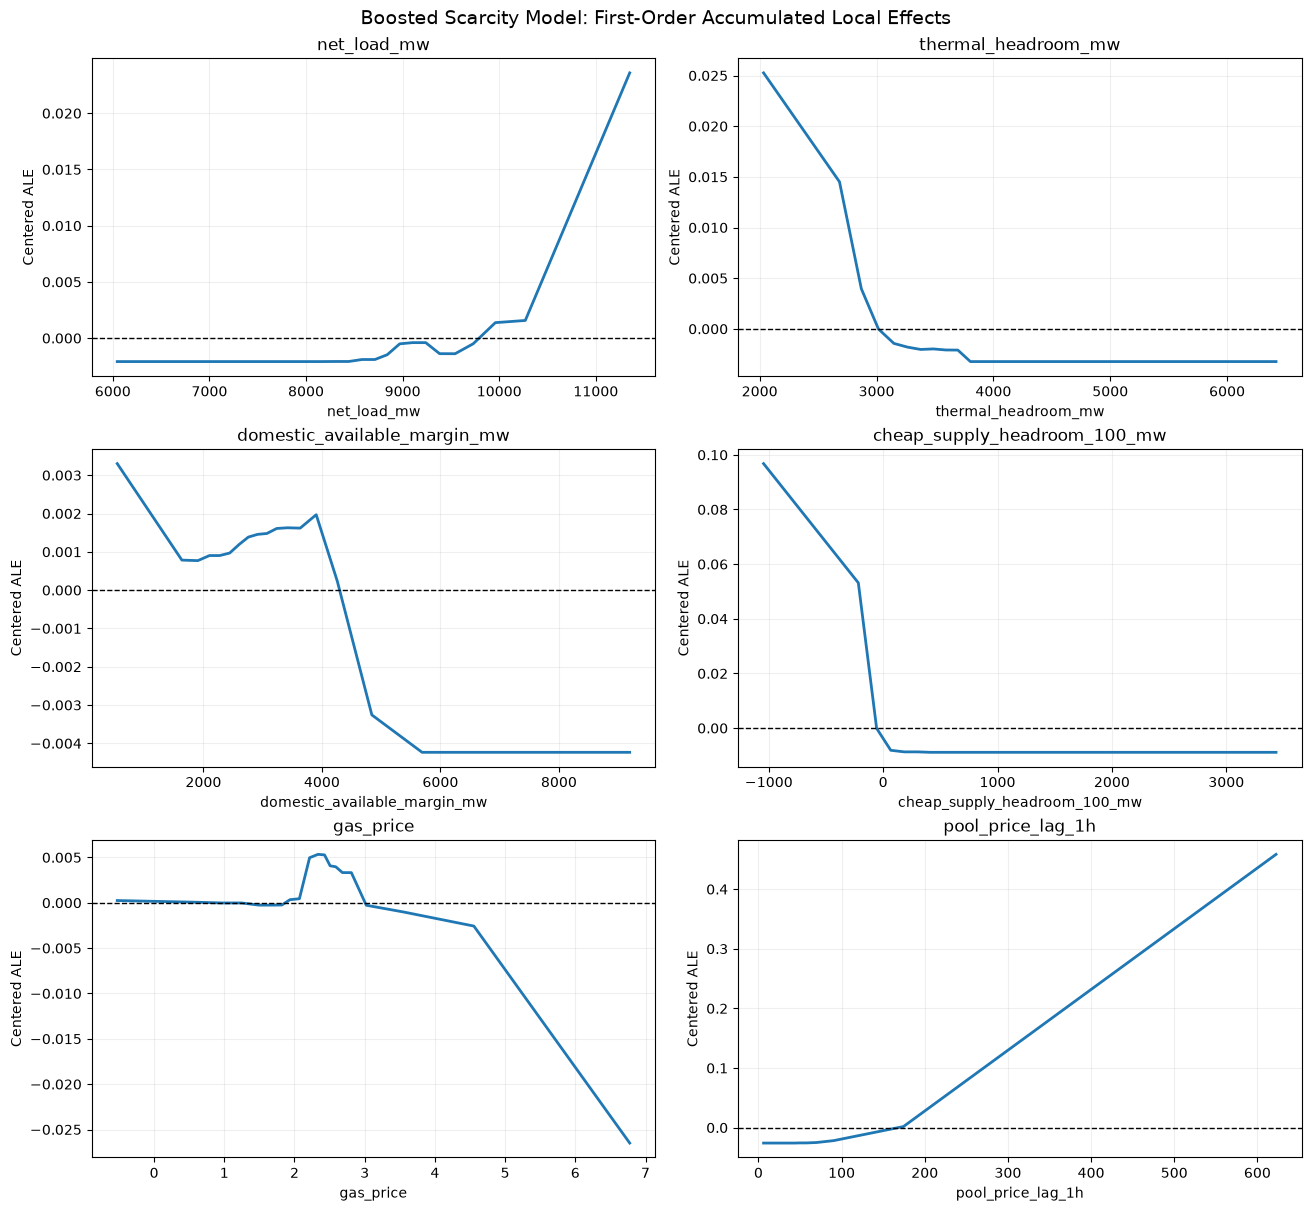

In [38]:
# ---------------------------------------------------------------------
# Plot boosted-model accumulated local effects
# ---------------------------------------------------------------------

FINAL_BOOSTED_YEAR = max(boosted_scarcity_result["fitted_models"])
FINAL_BOOSTED_SCARCITY_MODEL = boosted_scarcity_result["fitted_models"][FINAL_BOOSTED_YEAR]

ale_sample = model_features.loc[core_common_mask, CORE_FEATURES].sample(
    n=min(30000, int(core_common_mask.sum())), random_state=RANDOM_SEED
)

ALE_FEATURES = [
    "net_load_mw", "thermal_headroom_mw", "domestic_available_margin_mw",
    "cheap_supply_headroom_100_mw", "gas_price", "pool_price_lag_1h",
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12), constrained_layout=True)

for ax, feature in zip(axes.flat, ALE_FEATURES):
    ale = first_order_ale(
        FINAL_BOOSTED_SCARCITY_MODEL, ale_sample, feature, "scarcity", bins=20
    )
    ax.plot(ale.midpoint, ale.ale, linewidth=2)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set(title=feature, xlabel=feature, ylabel="Centered ALE")
    ax.grid(alpha=.20)

fig.suptitle(
    "Boosted Scarcity Model: First-Order Accumulated Local Effects", fontsize=14
)
plt.show()

## 15. Structural stability and model failure

Full-period performance can conceal structural failure.

This section asks:

- which models perform consistently across evaluation years;
- which years produce the largest errors;
- whether calibration shifts across regimes;
- whether models trained on earlier structures generalize into the coal-free market;
- whether recent rolling windows outperform expanding windows;
- whether the high-price 2022–2023 period dominates model conclusions.

Structural regimes are evaluation contexts, not core predictors.

In [39]:
# ---------------------------------------------------------------------
# Assemble all principal out-of-period predictions
# ---------------------------------------------------------------------

principal_predictions = pd.concat(
    [model_results[k]["predictions"] for k in [
        "Unconditional price median", "Unconditional scarcity rate"
    ]] + [
        r["predictions"] for r in [
            linear_price_result, additive_price_result,
            boosted_median_result, boosted_upper_quantile_result,
            linear_scarcity_result, additive_scarcity_result,
            boosted_scarcity_result,
        ]
    ], ignore_index=True
)

principal_metrics = summarize_prediction_frame(principal_predictions)

display(principal_metrics.sort_values(
    ["task", "evaluation_year", "model"]
).round(4))

,model,task,evaluation_year,hours,mae,median_absolute_error,bias,rmse,baseline_mae,brier_score,baseline_brier_score,brier_skill,log_loss,average_precision,roc_auc,calibration_intercept,calibration_slope,scarcity_base_rate,top_decile_scarcity_rate,top_decile_scarcity_lift,pinball_loss,baseline_pinball_loss
0,Core additive price location,price_location,2020,8784,8.5162,2.2719,-3.1565,37.4050,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,Core linear price location,price_location,2020,8784,13.9994,4.5675,-1.6762,64.7565,23.1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Core additive price location,price_location,2021,8760,29.2677,7.6602,-18.8803,73.3147,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,Core linear price location,price_location,2021,8760,37.5085,10.9067,-25.6197,88.6432,74.2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Core additive price location,price_location,2022,8760,54.3641,11.7773,8.1191,113.5322,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,Core linear price location,price_location,2022,8760,64.0591,12.1085,-4.2228,165.8520,132.6480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Core additive price location,price_location,2023,8759,52.3902,17.3611,-18.6836,101.4090,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,Core linear price location,price_location,2023,8759,57.6702,20.7003,-16.9602,115.2726,103.5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Core additive price location,price_location,2024,8784,21.0462,6.5060,1.5524,53.9934,45.5669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,Core linear price location,price_location,2024,8784,40.1977,23.2241,19.7254,110.6485,45.5669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


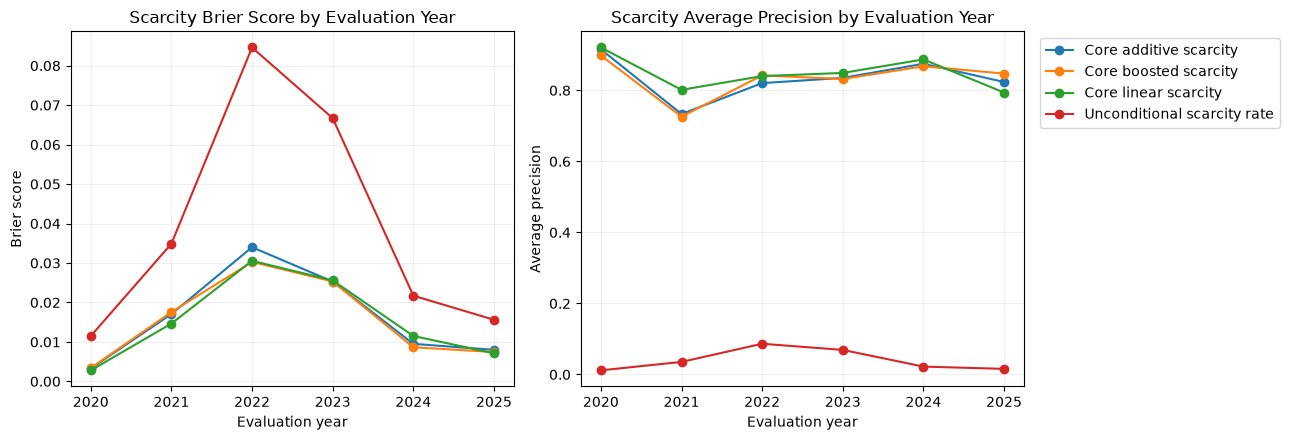

In [40]:
# ---------------------------------------------------------------------
# Plot metric stability across evaluation years
# ---------------------------------------------------------------------

scarcity_metric_plot = principal_metrics[principal_metrics.task.eq("scarcity")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, g in scarcity_metric_plot.groupby("model"):
    axes[0].plot(g.evaluation_year, g.brier_score, marker="o", label=name)
    axes[1].plot(g.evaluation_year, g.average_precision, marker="o", label=name)

axes[0].set(title="Scarcity Brier Score by Evaluation Year",
            xlabel="Evaluation year", ylabel="Brier score")
axes[1].set(title="Scarcity Average Precision by Evaluation Year",
            xlabel="Evaluation year", ylabel="Average precision")

for ax in axes: ax.grid(alpha=.20)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [41]:
# ---------------------------------------------------------------------
# Compare expanding and rolling training windows
# ---------------------------------------------------------------------

rolling_additive_scarcity_result = run_outer_evaluation(
    frame=model_features, model_name="Rolling-window additive scarcity",
    features=CORE_FEATURES, target="scarcity_500", task="scarcity",
    model_kind="additive", parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
    spline_features=CORE_SPLINE_FEATURES, sample_mask=core_common_mask,
    split_type="rolling", rolling_window_years=5,
)

window_comparison_metrics = summarize_prediction_frame(pd.concat(
    [additive_scarcity_result["predictions"],
     rolling_additive_scarcity_result["predictions"]], ignore_index=True
))

display(window_comparison_metrics[
    ["model", "evaluation_year", "brier_score", "average_precision",
     "calibration_slope", "top_decile_scarcity_lift"]
].sort_values(["evaluation_year", "model"]).round(4))

,model,evaluation_year,brier_score,average_precision,calibration_slope,top_decile_scarcity_lift
0,Core additive scarcity,2020,0.0033,0.9156,0.9387,9.9932
6,Rolling-window additive scarcity,2020,0.0033,0.9156,0.9387,9.9932
1,Core additive scarcity,2021,0.0171,0.7334,0.8559,9.2903
7,Rolling-window additive scarcity,2021,0.0175,0.7260,0.8122,9.0968
2,Core additive scarcity,2022,0.0340,0.8204,0.8072,7.8364
8,Rolling-window additive scarcity,2022,0.0369,0.8058,0.8080,7.6913
3,Core additive scarcity,2023,0.0253,0.8351,1.0823,8.4974
9,Rolling-window additive scarcity,2023,0.0268,0.8383,1.0862,8.5964
4,Core additive scarcity,2024,0.0095,0.8748,0.8835,9.9419
10,Rolling-window additive scarcity,2024,0.0094,0.8730,0.9021,9.8907


In [42]:
# ---------------------------------------------------------------------
# Diagnose residual error by structural regime
# ---------------------------------------------------------------------

scarcity_failure_profile = (
    complexity_predictions.assign(
        squared_probability_error=lambda x: (x.observed - x.prediction) ** 2,
        absolute_probability_error=lambda x: (x.observed - x.prediction).abs(),
    )
    .groupby(["model", "structural_regime"], observed=True)
    .agg(
        hours=("observed", "size"),
        scarcity_rate=("observed", "mean"),
        mean_prediction=("prediction", "mean"),
        brier_score=("squared_probability_error", "mean"),
        mean_absolute_probability_error=("absolute_probability_error", "mean"),
    )
    .reset_index()
)

display(scarcity_failure_profile.sort_values(
    ["model", "structural_regime"]
).round(4))

,model,structural_regime,hours,scarcity_rate,mean_prediction,brier_score,mean_absolute_probability_error
0,Core additive scarcity,Coal-free gas-renewable system,8760,0.0158,0.0074,0.0080,0.0105
1,Core additive scarcity,Coal-to-gas transition,17544,0.0235,0.0256,0.0102,0.0194
2,Core additive scarcity,Late coal exit and renewable buildout,26303,0.0593,0.0646,0.0229,0.0435
3,Core boosted scarcity,Coal-free gas-renewable system,8760,0.0158,0.0083,0.0074,0.0098
4,Core boosted scarcity,Coal-to-gas transition,17544,0.0235,0.0198,0.0105,0.0182
5,Core boosted scarcity,Late coal exit and renewable buildout,26303,0.0593,0.0590,0.0214,0.0399
6,Core linear scarcity,Coal-free gas-renewable system,8760,0.0158,0.0113,0.0071,0.0112
7,Core linear scarcity,Coal-to-gas transition,17544,0.0235,0.0213,0.0087,0.0174
8,Core linear scarcity,Late coal exit and renewable buildout,26303,0.0593,0.0610,0.0225,0.0436


### Stability decision


## 16. Robustness across scarcity thresholds


In [43]:
# ---------------------------------------------------------------------
# Evaluate threshold sensitivity
# ---------------------------------------------------------------------

threshold_results = {}
for threshold in SCARCITY_THRESHOLDS:
    target, name = f"scarcity_{threshold}", f"Additive scarcity ${threshold}+"
    mask = core_common_mask & model_features[target].notna()
    threshold_results[threshold] = run_outer_evaluation(
        frame=model_features, model_name=name, features=CORE_FEATURES,
        target=target, task="scarcity", model_kind="additive",
        parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
        spline_features=CORE_SPLINE_FEATURES, sample_mask=mask,
    )

threshold_predictions = pd.concat(
    [r["predictions"].assign(scarcity_threshold=t)
     for t, r in threshold_results.items()],
    ignore_index=True
)

threshold_metrics = summarize_prediction_frame(threshold_predictions)
threshold_metrics["scarcity_threshold"] = (
    threshold_metrics.model.str.extract(r"\$(\d+)").astype(float)
)

threshold_sensitivity = threshold_metrics.groupby("scarcity_threshold").agg(
    evaluation_years=("evaluation_year", "nunique"),
    mean_brier_score=("brier_score", "mean"),
    median_brier_skill=("brier_skill", "median"),
    mean_average_precision=("average_precision", "mean"),
    mean_roc_auc=("roc_auc", "mean"),
    median_calibration_slope=("calibration_slope", "median"),
    mean_top_decile_lift=("top_decile_scarcity_lift", "mean"),
)

display(threshold_sensitivity.round(4))


,evaluation_years,mean_brier_score,median_brier_skill,mean_average_precision,mean_roc_auc,median_calibration_slope,mean_top_decile_lift
scarcity_threshold,,,,,,,
100.0,6,0.0464,0.7098,0.8948,0.9750,0.9573,6.3265
300.0,6,0.0264,0.5769,0.8352,0.9791,0.9308,8.3668
500.0,6,0.0162,0.5801,0.8338,0.9860,0.9111,9.2599
900.0,6,0.0028,0.5404,0.8016,0.9970,1.0683,9.9675


## 17. Headline robustness tests

The following tests are limited to claims that could enter the evidence register:

- alternative physical-margin definition;
- inclusion of realized imports;
- inclusion of offer concentration;
- removal of 2022–2023;
- exclusion of dual-fuel reporting gaps;
- recent-regime-only estimation;
- common-sample versus maximum-coverage estimation.

The purpose is to attempt to falsify headline findings, not to search for the specification producing the best result.

In [44]:
# ---------------------------------------------------------------------
# Define key robustness specifications
# ---------------------------------------------------------------------

robustness_feature_sets = {
    "Primary core": CORE_FEATURES,
    "Thermal headroom only for adequacy": [f for f in CORE_FEATURES if f != "domestic_available_margin_mw"],
    "Available margin only for adequacy": [f for f in CORE_FEATURES if f != "thermal_headroom_mw"],
    "Core plus realized imports": [*CORE_FEATURES, "net_imports_mw"],
    "Core plus offer concentration": [*CORE_FEATURES, "offer_control_hhi"],
}

robustness_results = {}
for name, features in robustness_feature_sets.items():
    mask = model_features[["scarcity_500", *features]].notna().all(axis=1)
    splines = [f for f in features if f not in FEATURE_FAMILIES["Calendar"]]
    robustness_results[name] = run_outer_evaluation(
        frame=model_features, model_name=name, features=features,
        target="scarcity_500", task="scarcity", model_kind="additive",
        parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
        spline_features=splines, sample_mask=mask,
    )

robustness_metrics = summarize_prediction_frame(pd.concat(
    (r["predictions"] for r in robustness_results.values()), ignore_index=True
))

display(robustness_metrics[
    ["model", "evaluation_year", "brier_score", "average_precision",
     "calibration_slope", "top_decile_scarcity_lift"]
].sort_values(["evaluation_year", "model"]).round(4))


,model,evaluation_year,brier_score,average_precision,calibration_slope,top_decile_scarcity_lift
0,Available margin only for adequacy,2020,0.0031,0.9183,0.9892,9.9932
6,Core plus offer concentration,2020,0.0034,0.9102,0.8890,9.9932
12,Core plus realized imports,2020,0.0042,0.8983,0.8217,9.9932
18,Primary core,2020,0.0033,0.9156,0.9387,9.9932
24,Thermal headroom only for adequacy,2020,0.0030,0.9203,1.0080,9.9932
1,Available margin only for adequacy,2021,0.0167,0.7405,0.8950,9.2903
7,Core plus offer concentration,2021,0.0177,0.7241,0.8191,9.1613
13,Core plus realized imports,2021,0.0176,0.7382,0.8861,9.5484
19,Primary core,2021,0.0171,0.7334,0.8559,9.2903
25,Thermal headroom only for adequacy,2021,0.0163,0.7429,0.8686,9.1613


In [45]:
# ---------------------------------------------------------------------
# Test sensitivity to removal of 2022–2023
# ---------------------------------------------------------------------

excluding_2022_2023_mask = (
    core_common_mask & ~model_features.year_alberta.isin([2022, 2023])
)

excluding_2022_2023_result = run_outer_evaluation(
    frame=model_features, model_name="Additive scarcity excluding 2022–2023",
    features=CORE_FEATURES, target="scarcity_500", task="scarcity",
    model_kind="additive", parameter_grid=ADDITIVE_CLASSIFICATION_GRID,
    spline_features=CORE_SPLINE_FEATURES, sample_mask=excluding_2022_2023_mask,
)

anomalous_year_sensitivity = summarize_prediction_frame(pd.concat(
    [additive_scarcity_result["predictions"],
     excluding_2022_2023_result["predictions"]], ignore_index=True
))

display(anomalous_year_sensitivity[
    ["model", "evaluation_year", "brier_score", "average_precision",
     "calibration_slope", "top_decile_scarcity_lift"]
].sort_values(["evaluation_year", "model"]).round(4))


,model,evaluation_year,brier_score,average_precision,calibration_slope,top_decile_scarcity_lift
0,Additive scarcity excluding 2022–2023,2020,0.0033,0.9156,0.9387,9.9932
4,Core additive scarcity,2020,0.0033,0.9156,0.9387,9.9932
1,Additive scarcity excluding 2022–2023,2021,0.0171,0.7334,0.8559,9.2903
5,Core additive scarcity,2021,0.0171,0.7334,0.8559,9.2903
6,Core additive scarcity,2022,0.0340,0.8204,0.8072,7.8364
7,Core additive scarcity,2023,0.0253,0.8351,1.0823,8.4974
2,Additive scarcity excluding 2022–2023,2024,0.0217,0.8623,0.9827,9.8907
8,Core additive scarcity,2024,0.0095,0.8748,0.8835,9.9419
3,Additive scarcity excluding 2022–2023,2025,0.0080,0.8133,0.9930,9.9275
9,Core additive scarcity,2025,0.0080,0.8236,1.0328,10.0000


## 18. AESO API extensions and external price comparator

These are follow-up hypotheses outside the prespecified core. Each model
extension is tested against the unchanged core on identical timestamps and
reported by evaluation year. Forecast AIL and realized AIL forecast error are
alternative tests, not one combined feature set. The error is ex-post and
cannot be used as a target-hour forecast predictor.

The offer-stack test distinguishes flexible offered volume, import-offered
volume, and the shape of higher-priced available supply. Flexibility volume
does not measure physical ramp speed. Outage composition uses consistently
reported full-period categories; it does not treat unreported categories as
zero. The AESO pool-price forecast is an external comparator, not a physical
mechanism predictor; issue time and historical vintage remain unverified.


In [46]:
# ---------------------------------------------------------------------
# Screen AESO mechanisms against the unchanged core on identical hours
# ---------------------------------------------------------------------

API_EXTENSION_SPECIFICATIONS = {
    "Forecast AIL level": FEATURE_FAMILIES["Demand expectation"],
    "Realized demand surprise": FEATURE_FAMILIES["Demand surprise"],
    "Offer-stack shape": FEATURE_FAMILIES["Offer-stack shape"],
    "Outage composition": FEATURE_FAMILIES["Outage composition"],
}

api_extension_results = {}
api_extension_rows = []

for extension_name, extra_features in API_EXTENSION_SPECIFICATIONS.items():
    extended_features = list(dict.fromkeys([*CORE_FEATURES, *extra_features]))
    matched_mask = model_features[
        ["scarcity_500", *extended_features]
    ].notna().all(axis=1)

    if extension_name in {"Forecast AIL level", "Realized demand surprise"}:
        matched_mask &= model_features["aeso_load_reconciled"]

    results = {}
    for specification, features in {
        "Core": CORE_FEATURES,
        "Core plus extension": extended_features,
    }.items():
        results[specification] = run_outer_evaluation(
            frame=model_features,
            model_name=f"{extension_name}: {specification}",
            features=features,
            target="scarcity_500",
            task="scarcity",
            model_kind="linear",
            parameter_grid=LINEAR_CLASSIFICATION_GRID,
            sample_mask=matched_mask,
        )

    api_extension_results[extension_name] = results
    core_predictions = results["Core"]["predictions"]
    extended_predictions = results["Core plus extension"]["predictions"]

    assert core_predictions["timestamp_utc"].equals(
        extended_predictions["timestamp_utc"]
    ), f"Comparison hours differ for {extension_name}"

    core_metrics = summarize_prediction_frame(core_predictions)
    extended_metrics = summarize_prediction_frame(extended_predictions)
    paired = core_metrics.merge(
        extended_metrics,
        on="evaluation_year",
        suffixes=("_core", "_extended"),
        validate="one_to_one",
    )
    assert paired["hours_core"].equals(paired["hours_extended"])

    api_extension_rows.append(pd.DataFrame({
        "extension": extension_name,
        "evaluation_year": paired["evaluation_year"],
        "matched_hours": paired["hours_core"],
        "core_brier": paired["brier_score_core"],
        "extended_brier": paired["brier_score_extended"],
        "brier_improvement": (
            paired["brier_score_core"] - paired["brier_score_extended"]
        ),
        "average_precision_improvement": (
            paired["average_precision_extended"]
            - paired["average_precision_core"]
        ),
        "core_calibration_slope": paired["calibration_slope_core"],
        "extended_calibration_slope": paired["calibration_slope_extended"],
    }))

api_extension_comparison = pd.concat(api_extension_rows, ignore_index=True)
api_extension_summary = (
    api_extension_comparison.groupby("extension")
    .agg(
        evaluated_years=("evaluation_year", "nunique"),
        median_brier_improvement=("brier_improvement", "median"),
        years_brier_improved=(
            "brier_improvement", lambda series: int(series.gt(0).sum())
        ),
        median_ap_improvement=("average_precision_improvement", "median"),
        minimum_matched_hours=("matched_hours", "min"),
    )
    .sort_values("median_brier_improvement", ascending=False)
)

display(api_extension_comparison.round(6))
display(api_extension_summary.round(6))


,extension,evaluation_year,matched_hours,core_brier,extended_brier,brier_improvement,average_precision_improvement,core_calibration_slope,extended_calibration_slope
0,Forecast AIL level,2020,8784,0.002799,0.002774,0.000025,0.001807,1.188104,1.196332
1,Forecast AIL level,2021,8759,0.014639,0.014885,-0.000245,-0.010735,1.199446,1.130894
2,Forecast AIL level,2022,8759,0.030424,0.032210,-0.001785,-0.012078,0.901778,0.855895
3,Forecast AIL level,2023,8757,0.025594,0.026736,-0.001143,0.002386,1.199297,1.198691
4,Forecast AIL level,2024,8784,0.011677,0.010910,0.000766,0.000926,1.040589,1.043121
5,Forecast AIL level,2025,8760,0.007144,0.007039,0.000106,0.007762,1.034997,1.033691
6,Realized demand surprise,2020,8784,0.002799,0.002708,0.000091,0.008002,1.188104,1.268560
7,Realized demand surprise,2021,8759,0.014639,0.015771,-0.001131,-0.026524,1.199446,1.092571
8,Realized demand surprise,2022,8759,0.030424,0.029994,0.000430,0.004410,0.901778,0.926285
9,Realized demand surprise,2023,8757,0.025594,0.025531,0.000062,0.004990,1.199297,1.226262


,evaluated_years,median_brier_improvement,years_brier_improved,median_ap_improvement,minimum_matched_hours
extension,,,,,
Offer-stack shape,6,0.002854,6,0.029171,8759
Realized demand surprise,6,0.000132,5,0.005294,8757
Outage composition,6,0.000056,4,0.002969,8759
Forecast AIL level,6,-0.000110,3,0.001366,8757


In [47]:
# ---------------------------------------------------------------------
# Compare archived AESO price forecast with internal median-price estimate
# ---------------------------------------------------------------------

internal_price = boosted_median_result["predictions"][
    ["timestamp_utc", "evaluation_year", "observed", "prediction"]
].rename(columns={"prediction": "internal_median_estimate"})

price_comparator = (
    internal_price.merge(
        model_features[["timestamp_utc", "aeso_price_forecast_mwh"]],
        on="timestamp_utc",
        how="inner",
        validate="one_to_one",
    )
    .dropna(subset=["aeso_price_forecast_mwh"])
)

price_comparator_rows = []
for year, group in price_comparator.groupby("evaluation_year"):
    for label, column in [
        ("Internal contemporaneous model", "internal_median_estimate"),
        ("AESO archived price forecast", "aeso_price_forecast_mwh"),
    ]:
        error = group[column] - group["observed"]
        price_comparator_rows.append({
            "evaluation_year": year,
            "estimate": label,
            "matched_hours": len(group),
            "mae": error.abs().mean(),
            "median_absolute_error": error.abs().median(),
            "bias": error.mean(),
            "rmse": np.sqrt((error ** 2).mean()),
        })

price_comparator_summary = pd.DataFrame(price_comparator_rows)
display(price_comparator_summary.sort_values(
    ["evaluation_year", "estimate"]
).round(2))

print("AESO forecast issue-time verified: No")
print("Historical forecast-vintage integrity verified: No")


,evaluation_year,estimate,matched_hours,mae,median_absolute_error,bias,rmse
1,2020,AESO archived price forecast,8784,5.76,0.56,2.67,37.10
0,2020,Internal contemporaneous model,8784,7.10,1.51,-4.29,33.96
3,2021,AESO archived price forecast,8760,23.24,2.72,8.29,70.04
2,2021,Internal contemporaneous model,8760,26.78,8.18,-18.50,67.18
5,2022,AESO archived price forecast,8760,34.08,5.01,8.25,85.02
4,2022,Internal contemporaneous model,8760,42.22,8.49,-11.95,88.30
7,2023,AESO archived price forecast,8759,42.12,5.62,7.59,98.72
6,2023,Internal contemporaneous model,8759,38.20,9.39,-9.44,81.09
9,2024,AESO archived price forecast,8784,17.97,2.79,3.56,56.42
8,2024,Internal contemporaneous model,8784,17.68,4.43,0.99,48.53


AESO forecast issue-time verified: No
Historical forecast-vintage integrity verified: No


### API-extension interpretation


## 19. Unit-commitment sensitivity appendix

Unit-commitment directives are excluded from the core model because their archive begins in mid-2024.

This appendix asks only whether active directives add information within the available recent-regime sample. It cannot establish full-period stability or generalization across Alberta's structural transition.

In [48]:
# ---------------------------------------------------------------------
# Audit unit-commitment coverage
# ---------------------------------------------------------------------

unit_commitment_mask = model_features.unit_commitment_archive_available.eq(1)

unit_commitment_coverage = (
    model_features[unit_commitment_mask].groupby("year_alberta").agg(
        hours=("unit_commitment_archive_available", "size"),
        active_directive_hours=("unit_commitment_active_directives", lambda x: (x > 0).sum()),
        active_asset_hours=("unit_commitment_active_assets", lambda x: (x > 0).sum()),
        median_pool_price=("pool_price", "median"),
        scarcity_rate=("scarcity_500", "mean"),
    )
)

unit_commitment_coverage["scarcity_rate_pct"] = unit_commitment_coverage.scarcity_rate * 100
display(unit_commitment_coverage.round(3))


,hours,active_directive_hours,active_asset_hours,median_pool_price,scarcity_rate,scarcity_rate_pct
year_alberta,,,,,,
2024,4423,135,135,24.92,0.020,1.990
2025,8760,471,471,22.91,0.016,1.575


In [49]:
# ---------------------------------------------------------------------
# Compare recent-regime models with and without unit commitment
# ---------------------------------------------------------------------

recent_base_features = CORE_FEATURES
recent_commitment_features = [*CORE_FEATURES, *FEATURE_FAMILIES["Unit commitment"]]

recent_common_mask = (
    unit_commitment_mask
    & model_features[["scarcity_500", *recent_commitment_features]].notna().all(axis=1)
)

recent_feature_comparison = []

for label, features in {
    "Recent core without commitment": recent_base_features,
    "Recent core with commitment": recent_commitment_features,
}.items():
    frame = model_features.loc[recent_common_mask]
    if frame.empty:
        continue

    model = build_model(
        task="scarcity", model_kind="additive", features=features,
        parameters={"C": 1.0, "n_knots": 4},
        spline_features=[f for f in features if f not in FEATURE_FAMILIES["Calendar"]],
    )
    model.fit(frame[features], frame.scarcity_500)
    probability = model.predict_proba(frame[features])[:, 1]

    recent_feature_comparison.append({
        "model": label,
        "hours": len(frame),
        "brier_score_in_sample": brier_score_loss(frame.scarcity_500, probability),
        "average_precision_in_sample": safe_average_precision(frame.scarcity_500, probability),
        "roc_auc_in_sample": safe_roc_auc(frame.scarcity_500, probability),
    })

unit_commitment_sensitivity = pd.DataFrame(recent_feature_comparison)
display(unit_commitment_sensitivity.round(4))


,model,hours,brier_score_in_sample,average_precision_in_sample,roc_auc_in_sample
0,Recent core without commitment,13183,0.0043,0.9112,0.9972
1,Recent core with commitment,13183,0.0043,0.9116,0.9972


### Unit-commitment boundary


## 20. Scarcity onset and continuation diagnostic


In [50]:
# ---------------------------------------------------------------------
# Separate scarcity onset from continuation
# ---------------------------------------------------------------------

scarcity_state = model_features[
    "scarcity_500"
].astype(bool)

prior_scarcity_state = scarcity_state.shift(
    1,
    fill_value=False,
)

model_features[
    "scarcity_onset"
] = (
    scarcity_state
    & ~prior_scarcity_state
).astype("int8")

model_features[
    "scarcity_continuation"
] = (
    scarcity_state
    & prior_scarcity_state
).astype("int8")

best_scarcity_predictions = (
    boosted_scarcity_result["predictions"]
    .merge(
        model_features[
            [
                "timestamp_utc",
                "scarcity_onset",
                "scarcity_continuation",
            ]
        ],
        on="timestamp_utc",
        how="left",
        validate="one_to_one",
    )
)

best_scarcity_predictions[
    "scarcity_phase"
] = np.select(
    [
        best_scarcity_predictions[
            "scarcity_onset"
        ].eq(1),
        best_scarcity_predictions[
            "scarcity_continuation"
        ].eq(1),
    ],
    [
        "Onset",
        "Continuation",
    ],
    default="Non-scarcity",
)

phase_summary = (
    best_scarcity_predictions
    .groupby("scarcity_phase")
    .agg(
        hours=("observed", "size"),
        mean_predicted_probability=(
            "prediction",
            "mean",
        ),
        median_predicted_probability=(
            "prediction",
            "median",
        ),
        probability_90th_percentile=(
            "prediction",
            lambda series: series.quantile(0.90),
        ),
    )
)

display(phase_summary.round(4))

,hours,mean_predicted_probability,median_predicted_probability,probability_90th_percentile
scarcity_phase,,,,
Continuation,1478,0.7753,0.8906,0.9838
Non-scarcity,50498,0.0131,0.0001,0.0094
Onset,631,0.2662,0.1621,0.6810


### Onset-versus-continuation interpretation


## 21. Final evidence register


In [51]:
# ---------------------------------------------------------------------
# Create the final evidence-register template
# ---------------------------------------------------------------------

model_evidence_register = pd.DataFrame([
    {
        "finding": "Thermal headroom explains scarcity beyond net load",
        "target": "Scarcity ≥ $500/MWh",
        "mechanism_stage": "Physical supply adequacy",
        "primary_test": "Core model and leave-one-family-out ablation",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Moderate",
        "forecast_eligibility": "Requires forecast-vintage availability",
        "final_decision": "Pending",
    },
    {
        "finding": "Cheap-supply headroom adds information beyond physical tightness",
        "target": "Scarcity and upper-tail price",
        "mechanism_stage": "Offer stack",
        "primary_test": "Mechanism ladder, ablation, and interaction test",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "High",
        "forecast_eligibility": "Current merit order is not automatically forecast-safe",
        "final_decision": "Pending",
    },
    {
        "finding": "Net load retains information beyond upstream weather",
        "target": "Price and scarcity",
        "mechanism_stage": "Intermediate system state",
        "primary_test": "Alternative mechanism specifications",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Moderate",
        "forecast_eligibility": "Forecast-constructed net load required",
        "final_decision": "Pending",
    },
    {
        "finding": "Weather adds price or scarcity information after net load is known",
        "target": "Price and scarcity",
        "mechanism_stage": "Upstream weather",
        "primary_test": "Weather-versus-net-load comparison",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Low",
        "forecast_eligibility": "Archived weather forecasts required",
        "final_decision": "Pending",
    },
    {
        "finding": "Outages matter mainly through tight-state interactions",
        "target": "Scarcity ≥ $500/MWh",
        "mechanism_stage": "Conditional supply shock",
        "primary_test": "Outage ablation and explicit interactions",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Moderate",
        "forecast_eligibility": "Requires archived outage vintages",
        "final_decision": "Pending",
    },
    {
        "finding": "Import capability matters beyond physical tightness",
        "target": "Scarcity ≥ $500/MWh",
        "mechanism_stage": "External support",
        "primary_test": "Capability ablation and tightness interaction",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Lower than realized flow",
        "forecast_eligibility": "Requires forward capability information",
        "final_decision": "Pending",
    },
    {
        "finding": "Realized imports retain information after tightness",
        "target": "Price and scarcity",
        "mechanism_stage": "External support response",
        "primary_test": "Realized-import sensitivity",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "High",
        "forecast_eligibility": "Lag-only unless forecasted",
        "final_decision": "Pending",
    },
    {
        "finding": "Gas economics explain ordinary price better than scarcity",
        "target": "Median price versus scarcity",
        "mechanism_stage": "Fuel-cost level",
        "primary_test": "Price/scarcity ablation and gas × margin interaction",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Low to moderate",
        "forecast_eligibility": "Publication timing must be confirmed",
        "final_decision": "Pending",
    },
    {
        "finding": "Lagged price retains information beyond contemporaneous fundamentals",
        "target": "Price and scarcity",
        "mechanism_stage": "Market memory",
        "primary_test": "Core ablation and onset/continuation diagnostic",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Low",
        "forecast_eligibility": "Eligible when publication-safe",
        "final_decision": "Pending",
    },
    {
        "finding": "Prior volatility adds information beyond lagged price",
        "target": "Upper-tail price and scarcity",
        "mechanism_stage": "Market memory",
        "primary_test": "Within-family removal",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Low",
        "forecast_eligibility": "Eligible when prior-only",
        "final_decision": "Pending",
    },
    {
        "finding": "Offer-control concentration adds little conditional information",
        "target": "Price and scarcity",
        "mechanism_stage": "Offer concentration",
        "primary_test": "Offer-concentration sensitivity",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "High",
        "forecast_eligibility": "Current offer control is not forecast-safe",
        "final_decision": "Pending",
    },
    {
        "finding": "Unit commitment is associated with recent-regime stress",
        "target": "Price and scarcity",
        "mechanism_stage": "Operational intervention",
        "primary_test": "Short-history sensitivity appendix",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "Not fully testable",
        "regime_stability": "Not testable",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "High",
        "forecast_eligibility": "Issued-time treatment required",
        "final_decision": "Pending",
    },
])




new_evidence_rows = pd.DataFrame([
    {
        "finding": "Whether demand surprise adds information beyond realized physical state",
        "target": "Scarcity >= $500/MWh",
        "mechanism_stage": "Expected versus realized demand",
        "primary_test": "Matched core versus core plus signed AIL forecast error",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "Check post-2021 error-scale change",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Ex-post realized error",
        "forecast_eligibility": "Prohibited at target hour",
        "final_decision": "Pending",
    },
    {
        "finding": "Whether offer-stack shape adds information beyond cheap-supply headroom",
        "target": "Scarcity >= $500/MWh",
        "mechanism_stage": "Offer stack",
        "primary_test": "Matched offer-shape extension",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Same-hour offer snapshot",
        "forecast_eligibility": "Historical vintage required",
        "final_decision": "Pending",
    },
    {
        "finding": "Whether outage composition adds information beyond total outages",
        "target": "Scarcity >= $500/MWh",
        "mechanism_stage": "Unavailable supply composition",
        "primary_test": "Matched outage-composition extension",
        "functional_form": "To be completed",
        "incremental_result": "To be completed",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "To be completed",
        "endogeneity_concern": "Reported same-hour state",
        "forecast_eligibility": "Archived forward vintage required",
        "final_decision": "Pending",
    },
    {
        "finding": "AESO archived price forecast as an external comparator",
        "target": "Pool price",
        "mechanism_stage": "External benchmark, not mechanism",
        "primary_test": "Identical-hour price-error comparison",
        "functional_form": "Not applicable",
        "incremental_result": "Not a feature-ablation test",
        "chronological_result": "To be completed",
        "regime_stability": "To be completed",
        "redundancy_result": "Not applicable",
        "endogeneity_concern": "Issue time and vintage unverified",
        "forecast_eligibility": "Unverified",
        "final_decision": "Comparator only",
    },
])

model_evidence_register = pd.concat(
    [model_evidence_register, new_evidence_rows],
    ignore_index=True,
)

display(model_evidence_register)


,finding,target,mechanism_stage,primary_test,functional_form,incremental_result,chronological_result,regime_stability,redundancy_result,endogeneity_concern,forecast_eligibility,final_decision
0,Thermal headroom explains scarcity beyond net load,Scarcity ≥ $500/MWh,Physical supply adequacy,Core model and leave-one-family-out ablation,To be completed,To be completed,To be completed,To be completed,To be completed,Moderate,Requires forecast-vintage availability,Pending
1,Cheap-supply headroom adds information beyond physical tightness,Scarcity and upper-tail price,Offer stack,"Mechanism ladder, ablation, and interaction test",To be completed,To be completed,To be completed,To be completed,To be completed,High,Current merit order is not automatically forecast-safe,Pending
2,Net load retains information beyond upstream weather,Price and scarcity,Intermediate system state,Alternative mechanism specifications,To be completed,To be completed,To be completed,To be completed,To be completed,Moderate,Forecast-constructed net load required,Pending
3,Weather adds price or scarcity information after net load is known,Price and scarcity,Upstream weather,Weather-versus-net-load comparison,To be completed,To be completed,To be completed,To be completed,To be completed,Low,Archived weather forecasts required,Pending
4,Outages matter mainly through tight-state interactions,Scarcity ≥ $500/MWh,Conditional supply shock,Outage ablation and explicit interactions,To be completed,To be completed,To be completed,To be completed,To be completed,Moderate,Requires archived outage vintages,Pending
5,Import capability matters beyond physical tightness,Scarcity ≥ $500/MWh,External support,Capability ablation and tightness interaction,To be completed,To be completed,To be completed,To be completed,To be completed,Lower than realized flow,Requires forward capability information,Pending
6,Realized imports retain information after tightness,Price and scarcity,External support response,Realized-import sensitivity,To be completed,To be completed,To be completed,To be completed,To be completed,High,Lag-only unless forecasted,Pending
7,Gas economics explain ordinary price better than scarcity,Median price versus scarcity,Fuel-cost level,Price/scarcity ablation and gas × margin interaction,To be completed,To be completed,To be completed,To be completed,To be completed,Low to moderate,Publication timing must be confirmed,Pending
8,Lagged price retains information beyond contemporaneous fundamentals,Price and scarcity,Market memory,Core ablation and onset/continuation diagnostic,To be completed,To be completed,To be completed,To be completed,To be completed,Low,Eligible when publication-safe,Pending
9,Prior volatility adds information beyond lagged price,Upper-tail price and scarcity,Market memory,Within-family removal,To be completed,To be completed,To be completed,To be completed,To be completed,Low,Eligible when prior-only,Pending


## 22. Final synthesis
